# estimating probability of kind-linked

In [2]:
import gp
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

## import zarpie features
each row is a feature. columns: category (personality, physical, diet), split (train or test), in_heterogenous (whether or not it was used for train / test in heterogenous condition), 2d embedding, 384d embedding.

In [3]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

In [4]:
df.head()

,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
0,are angry,personality_behaviors,train,True,-0.073863,-0.238874,"[-0.02164809, 0.050021496, -0.027437702, 0.012..."
1,are brave,personality_behaviors,train,True,-0.100276,-0.269504,"[-0.022016477, -0.029494364, -0.042321444, 0.0..."
2,are curious,personality_behaviors,train,False,-0.085597,-0.184920,"[-0.06632441, 0.060695983, 0.0322907, 0.080090..."
3,are forgetful,personality_behaviors,train,False,-0.047072,-0.263889,"[-0.047100894, -0.008117868, -0.013956301, 0.0..."
4,are friendly,personality_behaviors,train,True,0.030569,-0.241963,"[-0.03688672, 0.047983356, -0.044930663, 0.021..."


In [5]:
phys_df = df[df['category'] == 'physical']
phys_df

,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
10,can roll their tongue,physical,test,False,-0.059797,0.049082,"[-0.04557631, 0.050970126, -0.024809176, -0.00..."
11,can see really far,physical,train,False,-0.149212,-0.076074,"[-0.009260512, 0.046762295, -0.07884355, 0.050..."
12,can snap with their toes,physical,test,False,-0.337391,0.194453,"[-0.051987637, 0.079508185, -0.015802959, 0.00..."
13,can touch their toes,physical,train,True,-0.334749,0.183512,"[-0.072572455, 0.071725756, -0.03638175, 0.001..."
14,can wiggle their ears,physical,test,False,-0.264249,0.042144,"[-0.033690855, 0.00076530117, -0.060950723, 0...."
16,draw circles on their knees,physical,train,False,-0.352429,0.129593,"[0.00054139935, 0.0146051245, -0.035719063, -0..."
26,have a flat belly button,physical,train,True,-0.193772,0.176596,"[-0.002618113, -0.027462484, -0.082157716, 0.0..."
27,have a loud voice,physical,train,False,-0.058055,-0.139414,"[-0.004545202, 0.013106136, -0.043702494, 0.08..."
28,have bony elbows,physical,train,False,-0.295247,0.285881,"[-0.015668994, 0.035148133, -0.067058556, 0.03..."
29,have cold hands and feet,physical,test,False,-0.293175,0.185171,"[-0.01657701, -0.0030899595, -0.14596134, -0.0..."


In [6]:
# 2d gp where the train features are 1 (kind-linked) and the test features are unknown / need to be predicted
# then other features possibly in the space should also be predicted

# Reload gp module to pick up changes
import importlib
importlib.reload(gp)

<module 'gp' from '/Users/mayamalaviya/Documents/PhD/GP Generics/compgenerics/model/gp/gp.py'>

In [7]:
# Extract training data (physical features in train split - these are kind-linked)
train_df = phys_df[phys_df['split'] == 'train']
train_coords = jnp.array(train_df[['x_2d', 'y_2d']].values)
train_labels = jnp.ones(len(train_coords))  # All training features are kind-linked (y=1)

# Extract test data (need to predict P(kind-linked))
test_df = phys_df[phys_df['split'] == 'test']
test_coords = jnp.array(test_df[['x_2d', 'y_2d']].values)

print(f"Training: {len(train_coords)} points")
print(f"Test: {len(test_coords)} points")

Training: 15 points
Test: 5 points


In [8]:
# Run Bernoulli GP classification
# prior_mean=0 means P(kind-linked) = .5
results = gp.bernoulli_gp_classify(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=test_coords,
    kernel_name="rbf_2d_ard",
    prior_mean=0,
    return_latent=True
)

# Show results
print("Predicted P(kind-linked) for test features:")
print("-" * 50)
for feat, prob in zip(test_df['feature'].values, results['probabilities']):
    print(f"  {feat}: {float(prob):.3f}")

Predicted P(kind-linked) for test features:
--------------------------------------------------
  can roll their tongue: 0.688
  can snap with their toes: 0.706
  can wiggle their ears: 0.716
  have cold hands and feet: 0.713
  snore when they sleep: 0.668


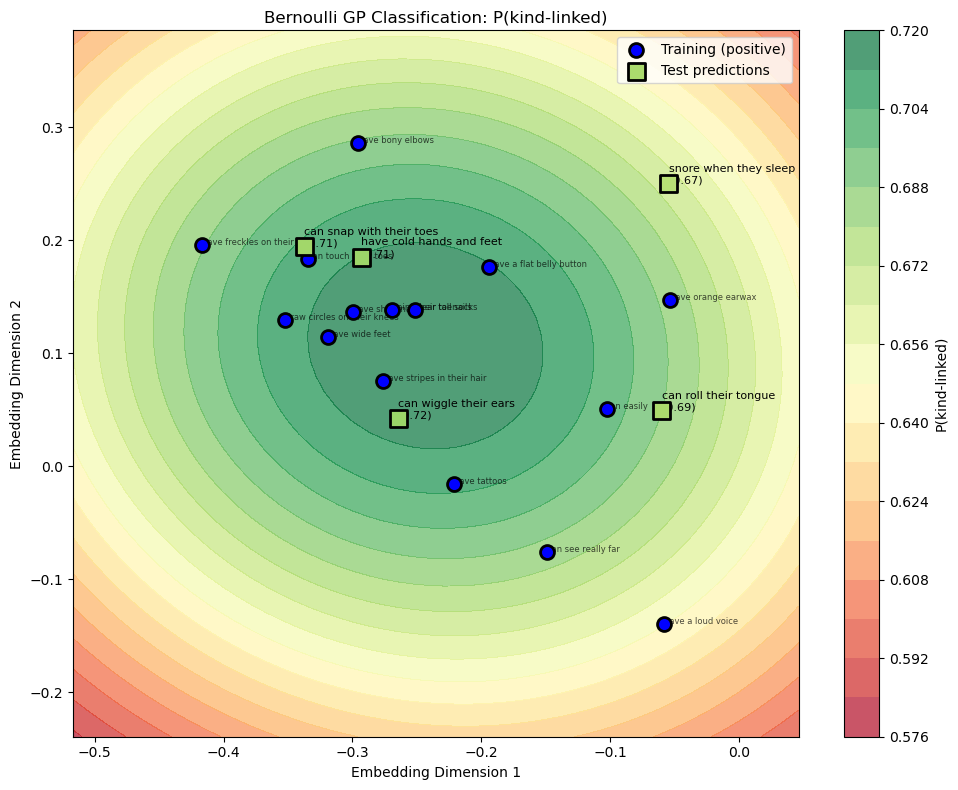

In [9]:
# Visualize the GP classification
gp.visualize_bernoulli_gp(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=test_coords,
    predictions=results,
    feature_names_train=list(train_df['feature'].values),
    feature_names_test=list(test_df['feature'].values),
    grid_resolution=50,
    kernel_name="rbf_2d_ard",
    prior_mean=0
)
plt.show()

In [10]:
# Show best hyperparameters found
print("Best hyperparameters (by marginal likelihood):")
spec = gp.get_kernel("rbf_2d_ard")
for name, val in zip(spec.param_names, results['best_params']):
    print(f"  {name}: {float(val):.4f}")

Best hyperparameters (by marginal likelihood):
  sigma: 0.5000
  lengthscale_x: 0.3000
  lengthscale_y: 0.3000


## Predict on all features (not just physical)

We can also predict P(kind-linked) for features from other categories to see how the model generalizes.

In [11]:
# Predict on ALL features in the dataframe
all_coords = jnp.array(df[['x_2d', 'y_2d']].values)

# Get predictions for all features
all_probs, all_f_mean, all_f_var = gp.laplace_predict(
    X_train=train_coords,
    y_train=train_labels,
    X_test=all_coords,
    kernel_params=results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=0
)

In [12]:
# Add predictions to dataframe for analysis
df_with_preds = df.copy()
df_with_preds['p_kind_linked'] = np.array(all_probs)
df_with_preds['latent_mean'] = np.array(all_f_mean)
df_with_preds['latent_var'] = np.array(all_f_var)

# Show predictions by category
for cat in df['category'].unique():
    print(f"\n{cat.upper()}:")
    cat_df = df_with_preds[df_with_preds['category'] == cat].sort_values('p_kind_linked', ascending=False)
    for _, row in cat_df.iterrows():
        marker = "✓" if row['split'] == 'train' else "?"
        print(f"  {marker} {row['feature']}: {row['p_kind_linked']:.3f}")


PERSONALITY_BEHAVIORS:
  ✓ can do cartwheels: 0.709
  ? like to dance: 0.660
  ✓ live with their families: 0.657
  ? cry easily: 0.655
  ✓ like to ride bikes: 0.644
  ✓ are curious: 0.639
  ✓ tell bad jokes: 0.636
  ✓ teach children: 0.627
  ✓ are silly: 0.624
  ✓ are angry: 0.617
  ✓ are brave: 0.610
  ✓ are smart: 0.606
  ✓ take care of others: 0.606
  ✓ are forgetful: 0.604
  ? like to give high-fives: 0.597
  ✓ are friendly: 0.596
  ? like to read books: 0.595
  ? like to collect rocks: 0.586
  ✓ give good gifts: 0.585
  ✓ are thoughtful: 0.561

DIET_PREFERENCES:
  ✓ farm potatoes: 0.600
  ✓ make bread: 0.588
  ✓ really don't like ice cream: 0.586
  ✓ eat cheese: 0.581
  ✓ eat nuts: 0.579
  ✓ like to eat sweets: 0.572
  ✓ like to drink fizzy water: 0.566
  ✓ really don't like soup: 0.565
  ✓ drink milk: 0.564
  ? like juice with pulp: 0.562
  ? eat breakfast very late: 0.561
  ✓ eat meat: 0.561
  ✓ like to eat herbs: 0.558
  ✓ like to drink tea: 0.557
  ? can eat spicy food: 0.551

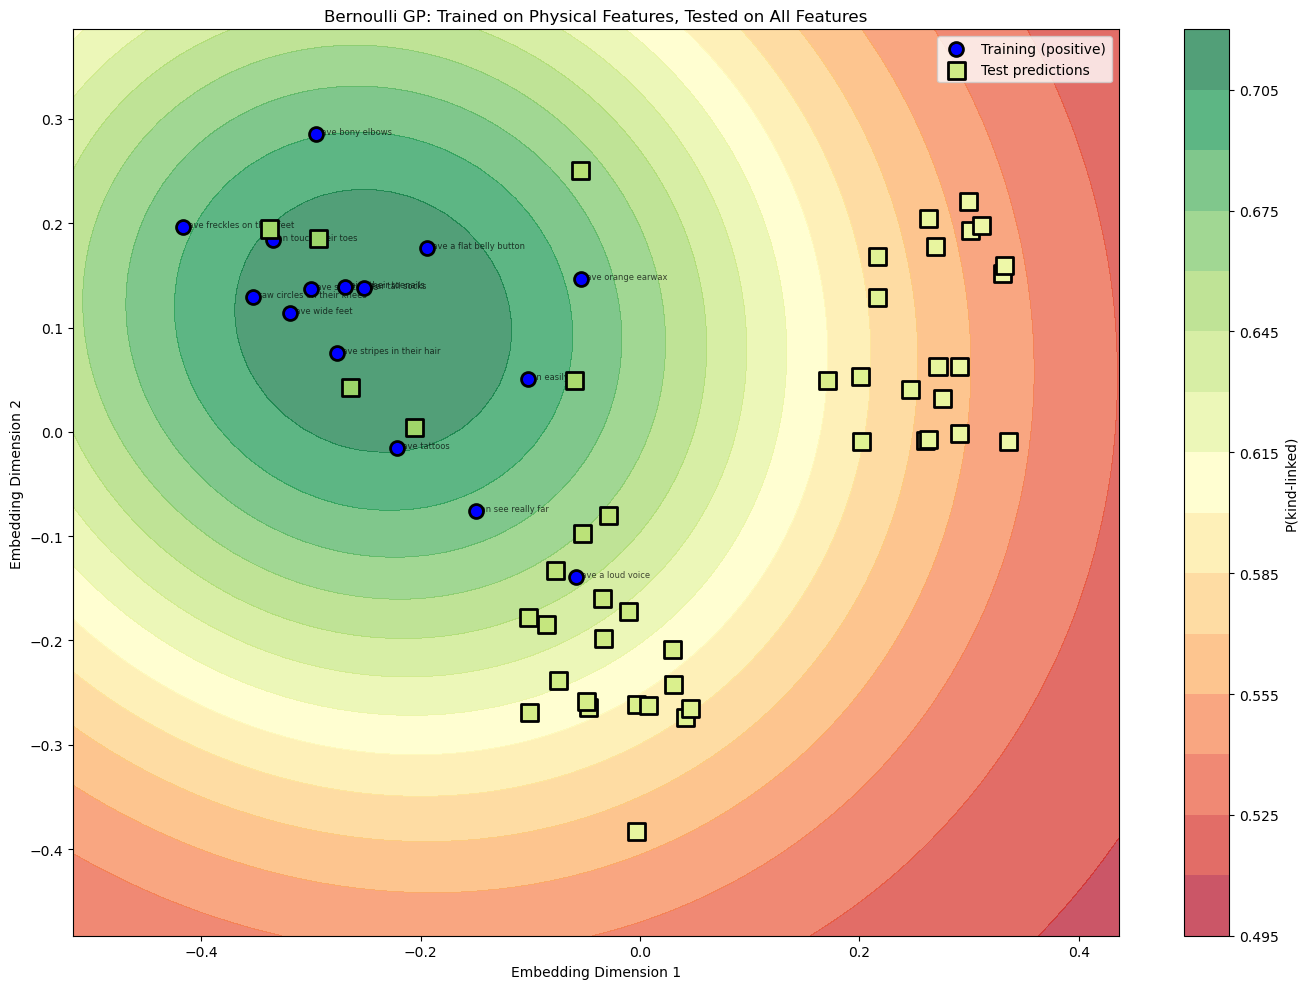

In [13]:
# Visualize: trained on physical features, tested on ALL features
# Create a results dict for all features
all_results = {
    'probabilities': all_probs,
    'best_params': results['best_params'],
}

# Get all non-training features as "test" for visualization
non_train_mask = ~((df['category'] == 'physical') & (df['split'] == 'train'))
all_test_coords = jnp.array(df[non_train_mask][['x_2d', 'y_2d']].values)
all_test_names = list(df[non_train_mask]['feature'].values)

# Get predictions just for non-training features
all_test_probs, _, _ = gp.laplace_predict(
    X_train=train_coords,
    y_train=train_labels,
    X_test=all_test_coords,
    kernel_params=results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=0
)

all_test_results = {
    'probabilities': all_test_probs,
    'best_params': results['best_params'],
}

# Visualize with all features
fig, ax = plt.subplots(figsize=(14, 10))
gp.visualize_bernoulli_gp(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=all_test_coords,
    predictions=all_test_results,
    feature_names_train=list(train_df['feature'].values),
    feature_names_test=None,  # Too many to label
    grid_resolution=60,
    kernel_name="rbf_2d_ard",
    prior_mean=0,
    ax=ax
)
ax.set_title('Bernoulli GP: Trained on Physical Features, Tested on All Features')
plt.tight_layout()
plt.show()

Heterogenous training features: 15
['are angry', 'are brave', 'are friendly', 'can touch their toes', 'eat rice', 'have a flat belly button', 'have freckles on their feet', 'have orange earwax', 'like to eat broccoli', 'like to eat herbs', 'like to ride bikes', 'make bread', "really don't like soup", 'tan easily', 'tell bad jokes']


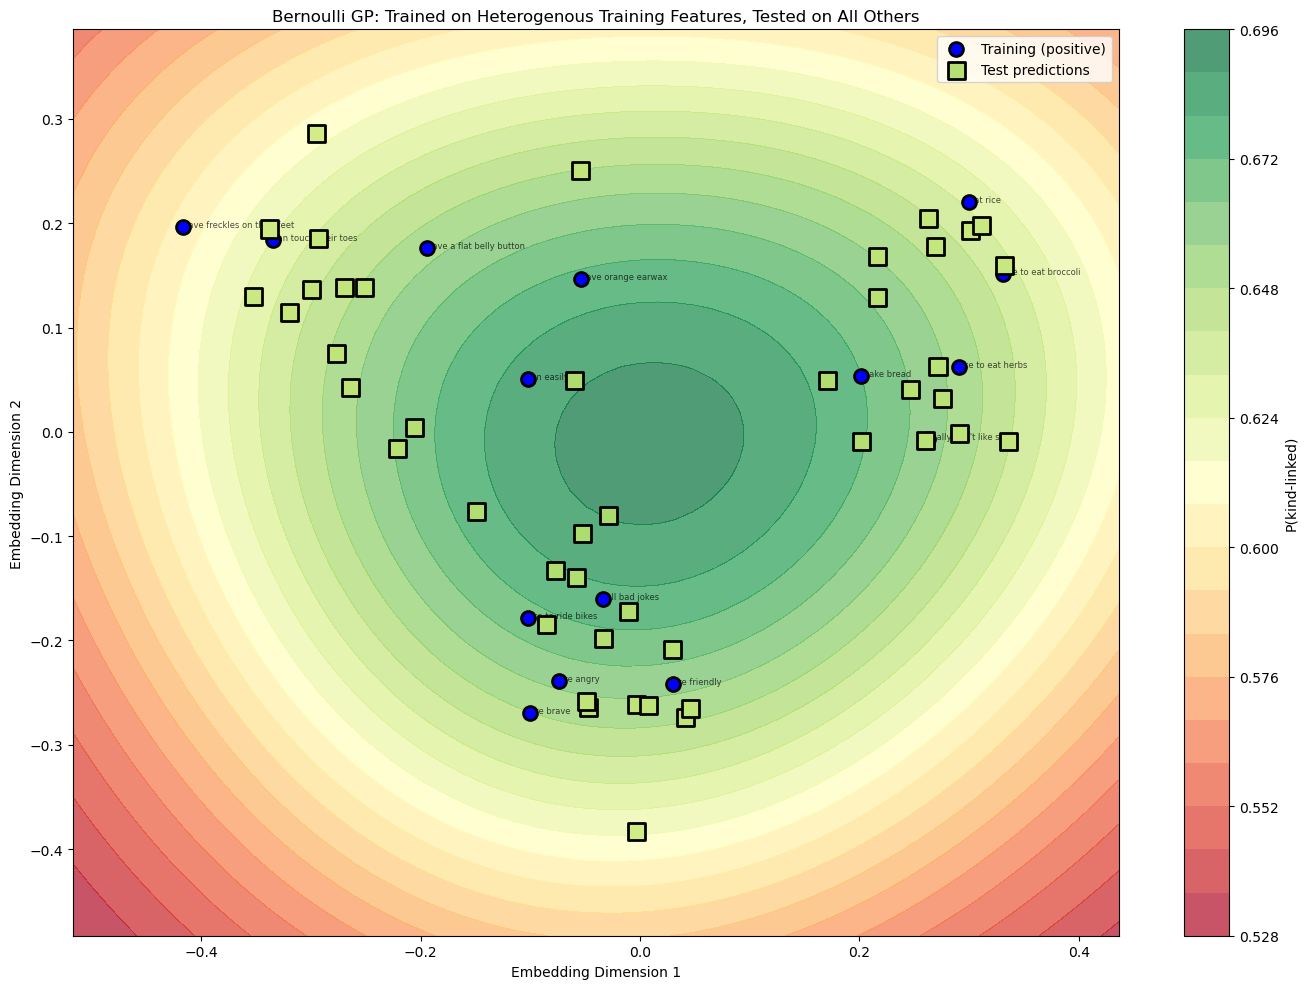

In [14]:
# Train on heterogenous training features only, test on all others
hetero_train_df = df[(df['in_heterogenous'] == True) & (df['split'] == 'train')]
hetero_train_coords = jnp.array(hetero_train_df[['x_2d', 'y_2d']].values)
hetero_train_labels = jnp.ones(len(hetero_train_coords))

print(f"Heterogenous training features: {len(hetero_train_coords)}")
print(hetero_train_df['feature'].tolist())

# Run classification
hetero_results = gp.bernoulli_gp_classify(
    train_coords=hetero_train_coords,
    train_labels=hetero_train_labels,
    test_coords=jnp.array(df[['x_2d', 'y_2d']].values),  # dummy, we'll predict separately
    kernel_name="rbf_2d_ard",
    prior_mean=0,
    return_latent=False
)

# Get all non-heterogenous-training features as "test"
non_hetero_train_mask = ~((df['in_heterogenous'] == True) & (df['split'] == 'train'))
hetero_test_coords = jnp.array(df[non_hetero_train_mask][['x_2d', 'y_2d']].values)
hetero_test_names = list(df[non_hetero_train_mask]['feature'].values)

# Get predictions for test features
hetero_test_probs, _, _ = gp.laplace_predict(
    X_train=hetero_train_coords,
    y_train=hetero_train_labels,
    X_test=hetero_test_coords,
    kernel_params=hetero_results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=0
)

hetero_test_results = {
    'probabilities': hetero_test_probs,
    'best_params': hetero_results['best_params'],
}

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))
gp.visualize_bernoulli_gp(
    train_coords=hetero_train_coords,
    train_labels=hetero_train_labels,
    test_coords=hetero_test_coords,
    predictions=hetero_test_results,
    feature_names_train=list(hetero_train_df['feature'].values),
    feature_names_test=None,
    grid_resolution=60,
    kernel_name="rbf_2d_ard",
    prior_mean=0,
    ax=ax
)
ax.set_title('Bernoulli GP: Trained on Heterogenous Training Features, Tested on All Others')
# plt.tight_layout()
plt.show()

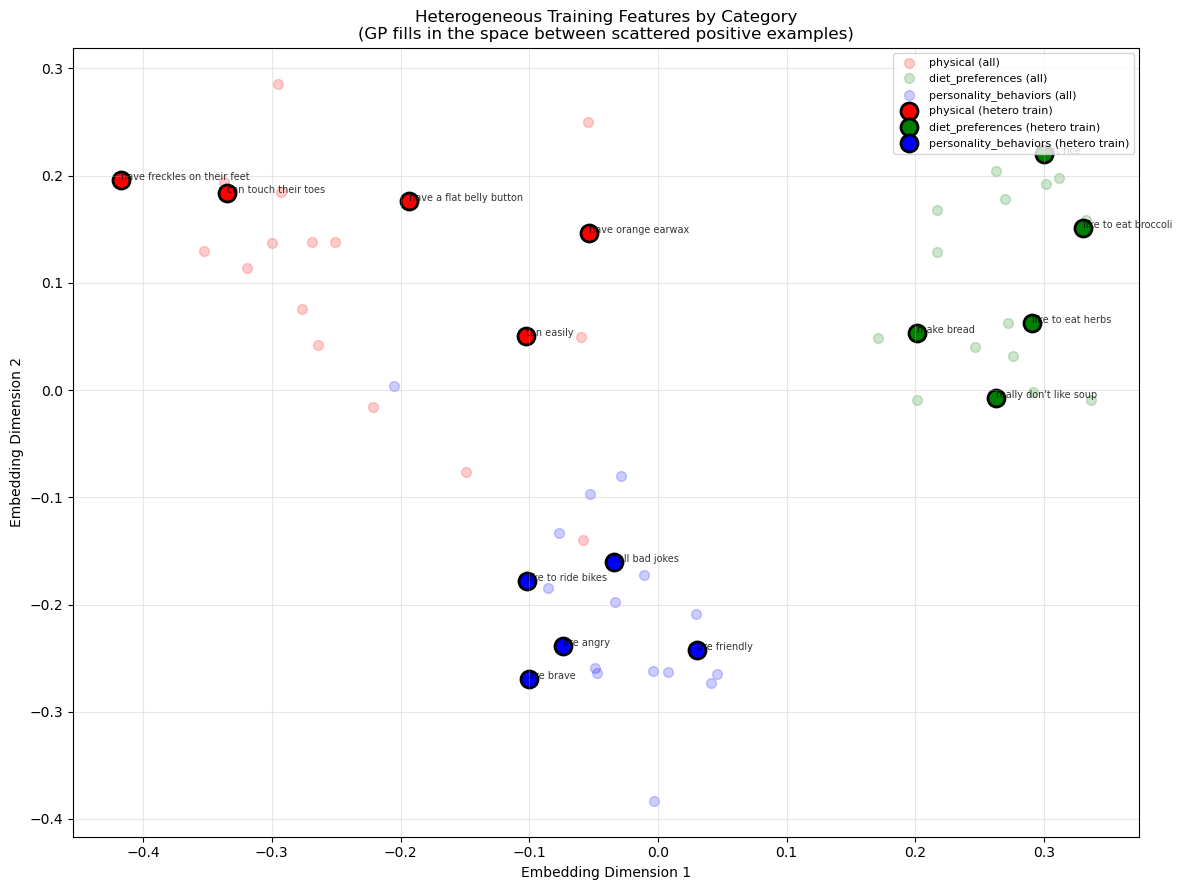


Heterogeneous training features by category:

physical: 5 features
  - can touch their toes
  - have a flat belly button
  - have freckles on their feet
  - have orange earwax
  - tan easily

diet_preferences: 5 features
  - eat rice
  - like to eat broccoli
  - like to eat herbs
  - make bread
  - really don't like soup

personality_behaviors: 5 features
  - are angry
  - are brave
  - are friendly
  - like to ride bikes
  - tell bad jokes


In [15]:
# Visualize WHERE the heterogeneous training points are by category
# This explains why there's a high-probability region in the middle

fig, ax = plt.subplots(figsize=(12, 9))

# Plot ALL features by category (faded)
colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}
for cat, color in colors.items():
    cat_df = df[df['category'] == cat]
    ax.scatter(cat_df['x_2d'], cat_df['y_2d'], 
               c=color, alpha=0.2, s=50, label=f'{cat} (all)')

# Highlight heterogeneous training features
hetero_train = df[(df['in_heterogenous'] == True) & (df['split'] == 'train')]
for cat, color in colors.items():
    cat_hetero = hetero_train[hetero_train['category'] == cat]
    ax.scatter(cat_hetero['x_2d'], cat_hetero['y_2d'], 
               c=color, s=150, edgecolors='black', linewidths=2,
               label=f'{cat} (hetero train)', marker='o')
    # Label them
    for _, row in cat_hetero.iterrows():
        ax.annotate(row['feature'], (row['x_2d'], row['y_2d']), 
                   fontsize=7, alpha=0.8)

ax.set_xlabel('Embedding Dimension 1')
ax.set_ylabel('Embedding Dimension 2')
ax.set_title('Heterogeneous Training Features by Category\n(GP fills in the space between scattered positive examples)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHeterogeneous training features by category:")
for cat in colors.keys():
    cat_hetero = hetero_train[hetero_train['category'] == cat]
    print(f"\n{cat}: {len(cat_hetero)} features")
    for _, row in cat_hetero.iterrows():
        print(f"  - {row['feature']}")

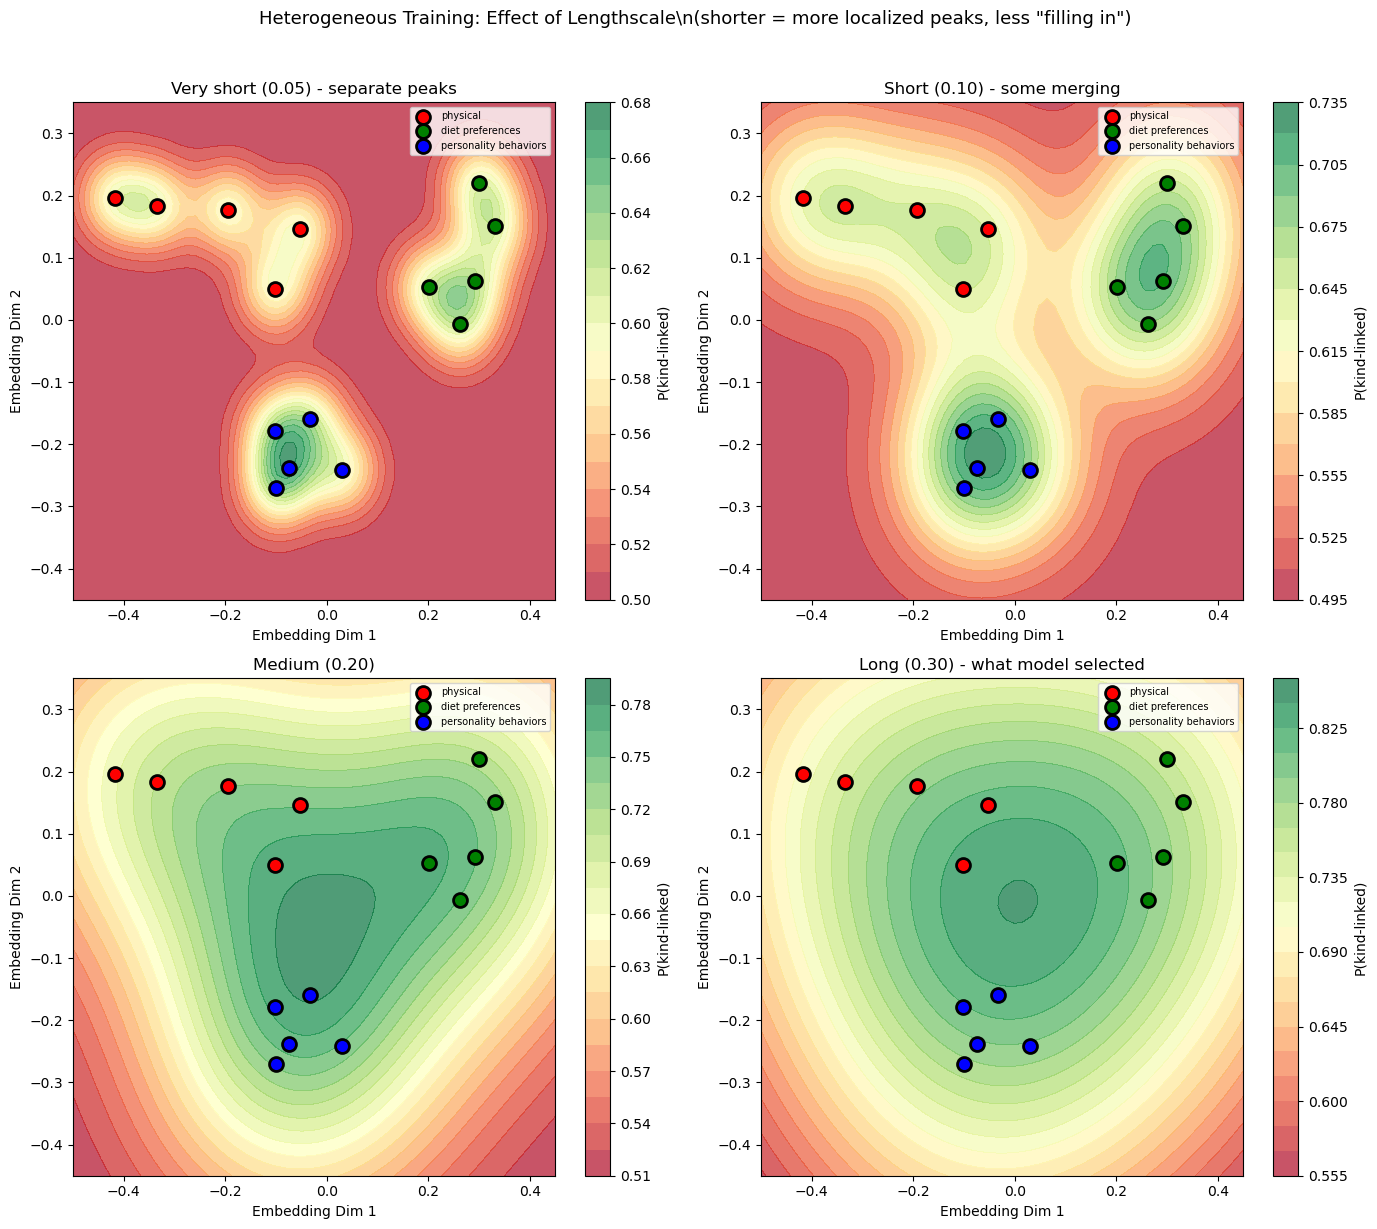

In [16]:
# Compare lengthscales for the HETEROGENEOUS training case
# Shorter lengthscales = more localized peaks around each training point

lengthscale_settings = [
    (0.05, 0.05, "Very short (0.05) - separate peaks"),
    (0.10, 0.10, "Short (0.10) - some merging"),
    (0.20, 0.20, "Medium (0.20)"),
    (0.30, 0.30, "Long (0.30) - what model selected"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Color markers by category
cat_colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}

for ax, (lx, ly, title) in zip(axes, lengthscale_settings):
    manual_params = jnp.array([1.0, lx, ly])
    
    # Create grid
    x_min, x_max = -0.5, 0.45
    y_min, y_max = -0.45, 0.35
    xx, yy = jnp.meshgrid(
        jnp.linspace(x_min, x_max, 60),
        jnp.linspace(y_min, y_max, 60)
    )
    grid_coords = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
    
    # Predict using heterogeneous training data
    probs_grid, _, _ = gp.laplace_predict(
        X_train=hetero_train_coords,
        y_train=hetero_train_labels,
        X_test=grid_coords,
        kernel_params=manual_params,
        kernel_name="rbf_2d_ard",
        prior_mean=0
    )
    probs_grid = probs_grid.reshape(xx.shape)
    
    # Plot heatmap
    im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='RdYlGn', alpha=0.7)
    plt.colorbar(im, ax=ax, label='P(kind-linked)')
    
    # Plot heterogeneous training points colored by category
    for cat, color in cat_colors.items():
        cat_mask = hetero_train_df['category'] == cat
        cat_coords = hetero_train_coords[cat_mask.values]
        ax.scatter(cat_coords[:, 0], cat_coords[:, 1], 
                   c=color, s=100, edgecolors='black', linewidths=2,
                   label=cat.replace('_', ' '), zorder=5)
    
    ax.set_xlabel('Embedding Dim 1')
    ax.set_ylabel('Embedding Dim 2')
    ax.set_title(f'{title}')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='upper right', fontsize=7)

plt.suptitle('Heterogeneous Training: Effect of Lengthscale\\n(shorter = more localized peaks, less "filling in")', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

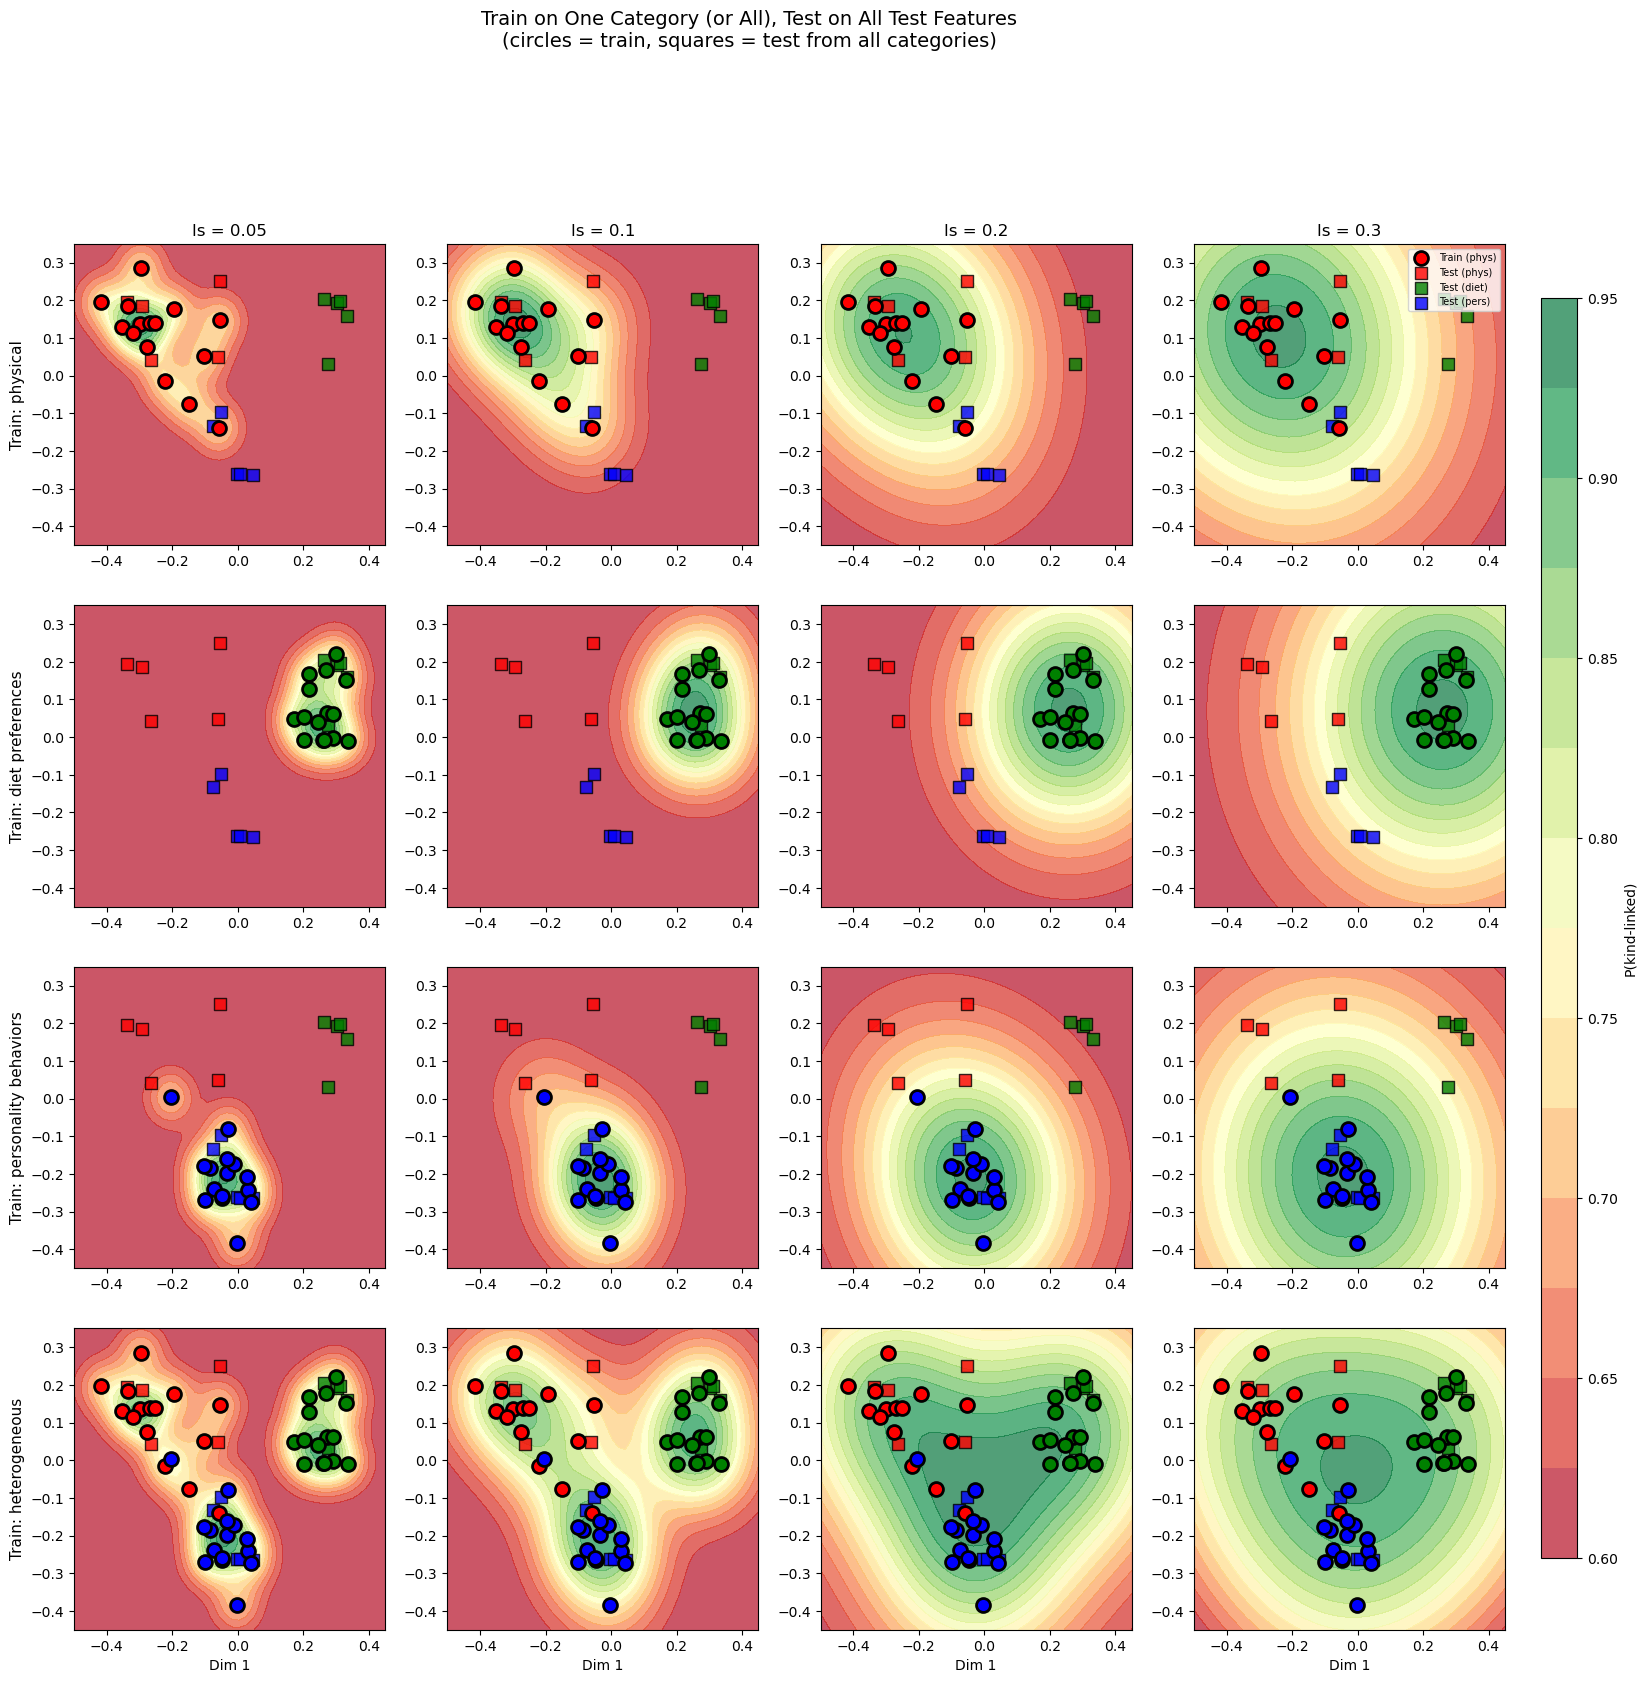

In [17]:
# Compare training on each category separately, with different lengthscales
# Train on split=='train' for one category, test on ALL split=='test' features

training_categories = [
    ('physical', 'red'),
    ('diet_preferences', 'green'),
    ('personality_behaviors', 'blue'),
    ('heterogeneous', 'purple'),  # All categories combined
]

lengthscales = [0.05, 0.10, 0.20, 0.30]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

# Color markers by category
cat_colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}

# Grid setup
x_min, x_max = -0.5, 0.45
y_min, y_max = -0.45, 0.35
xx, yy = jnp.meshgrid(
    jnp.linspace(x_min, x_max, 50),
    jnp.linspace(y_min, y_max, 50)
)
grid_coords = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

# Get ALL test features (from all categories)
all_test_df = df[df['split'] == 'test']

for row, (train_cat, train_color) in enumerate(training_categories):
    # Get TRAINING data
    if train_cat == 'heterogeneous':
        # Train on ALL training data from all categories
        cat_train_df = df[df['split'] == 'train']
    else:
        # Train on this category only (split == 'train')
        cat_train_df = df[(df['category'] == train_cat) & (df['split'] == 'train')]
    
    cat_train_coords = jnp.array(cat_train_df[['x_2d', 'y_2d']].values)
    cat_train_labels = jnp.ones(len(cat_train_coords))
    
    for col, ls in enumerate(lengthscales):
        ax = axes[row, col]
        manual_params = jnp.array([1.0, ls, ls])
        
        # Predict on grid
        probs_grid, _, _ = gp.laplace_predict(
            X_train=cat_train_coords,
            y_train=cat_train_labels,
            X_test=grid_coords,
            kernel_params=manual_params,
            kernel_name="rbf_2d_ard",
            prior_mean=0
        )
        probs_grid = probs_grid.reshape(xx.shape)
        
        # Plot heatmap
        im = ax.contourf(xx, yy, probs_grid, levels=15, cmap='RdYlGn', alpha=0.7)
        
        # Plot training points (circles with black edge)
        if train_cat == 'heterogeneous':
            # For heterogeneous, color training points by their actual category
            for train_cat_name, train_cat_color in cat_colors.items():
                train_cat_subset = cat_train_df[cat_train_df['category'] == train_cat_name]
                ax.scatter(train_cat_subset['x_2d'], train_cat_subset['y_2d'], 
                           c=train_cat_color, s=100, marker='o',
                           edgecolors='black', linewidths=2,
                           label=f'Train ({train_cat_name[:4]})', zorder=5)
        else:
            ax.scatter(cat_train_coords[:, 0], cat_train_coords[:, 1], 
                       c=train_color, s=100, marker='o',
                       edgecolors='black', linewidths=2,
                       label=f'Train ({train_cat[:4]})', zorder=5)
        
        # Plot ALL test points, colored by their category
        for test_cat, test_color in cat_colors.items():
            test_cat_df = all_test_df[all_test_df['category'] == test_cat]
            ax.scatter(test_cat_df['x_2d'], test_cat_df['y_2d'], 
                       c=test_color, s=80, marker='s', alpha=0.8,
                       edgecolors='black', linewidths=1,
                       label=f'Test ({test_cat[:4]})', zorder=4)
        
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        # Labels
        if row == 0:
            ax.set_title(f'ls = {ls}', fontsize=12)
        if col == 0:
            ax.set_ylabel(f'Train: {train_cat.replace("_", " ")}', fontsize=11)
        if row == 3:
            ax.set_xlabel('Dim 1', fontsize=10)
        if row == 0 and col == 3:
            ax.legend(loc='upper right', fontsize=7)

# Add single colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='P(kind-linked)')

plt.suptitle('Train on One Category (or All), Test on All Test Features\n(circles = train, squares = test from all categories)', 
             fontsize=14, y=1.01)
# plt.tight_layout(rect=[0, 0, 0.92, 0.98])
plt.show()

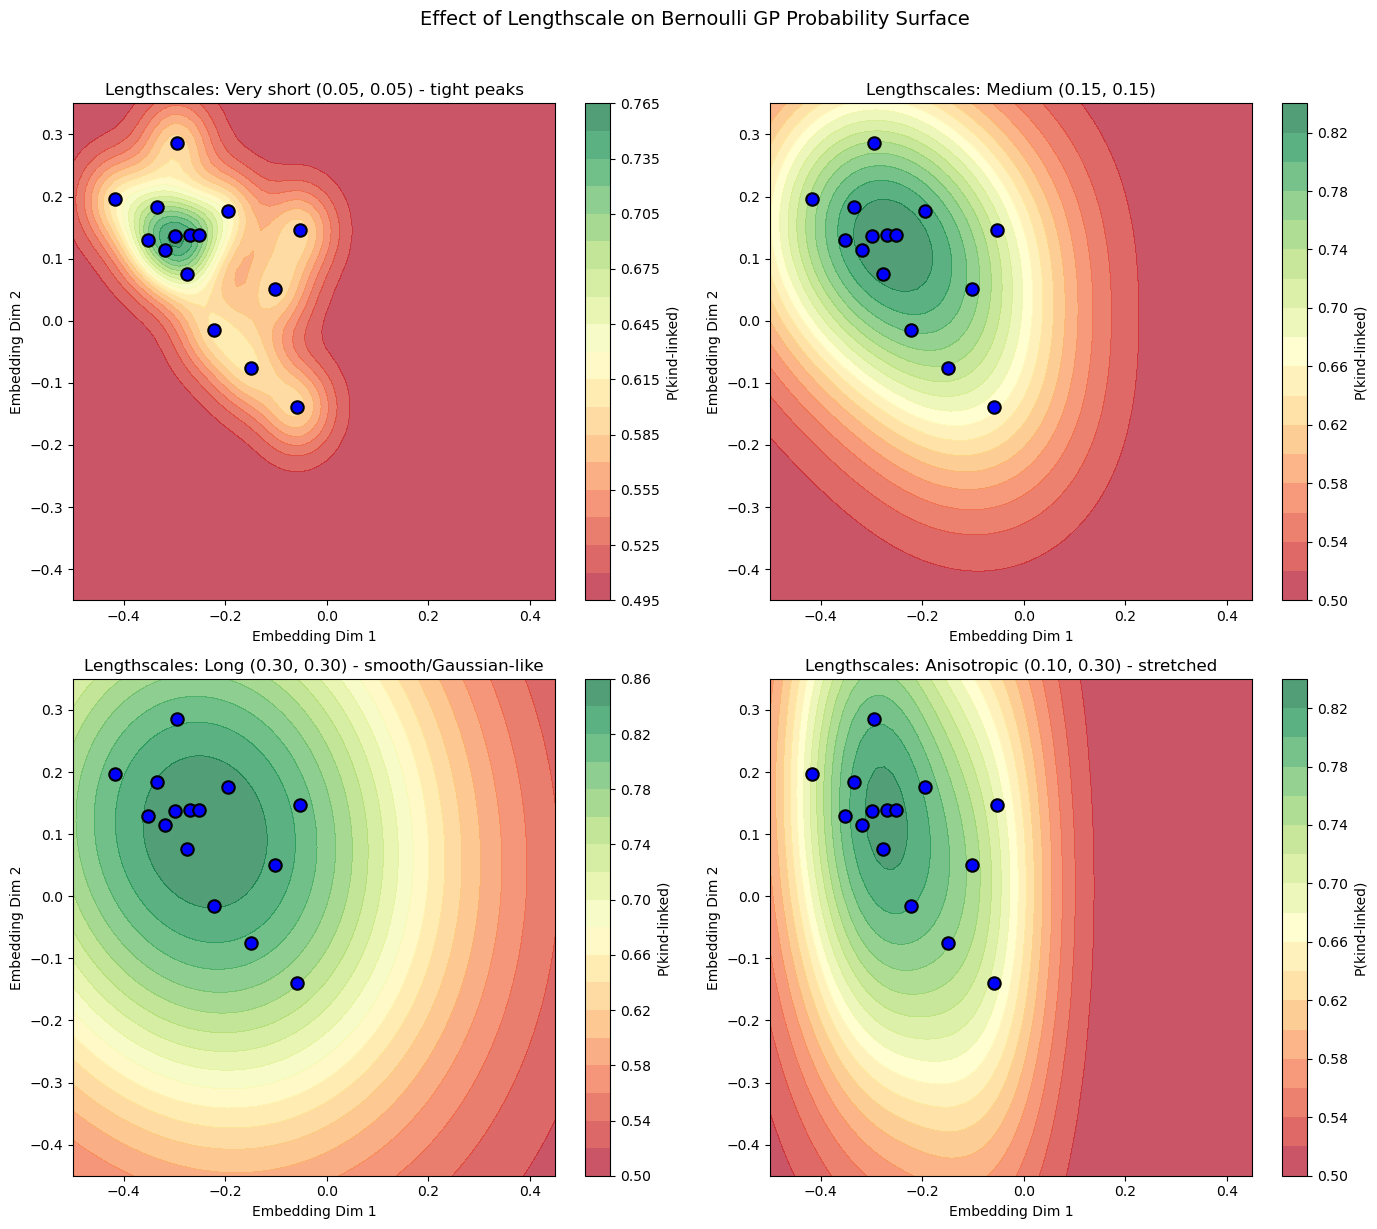

In [18]:
# Compare different lengthscales to see how they affect the probability surface
# Using the physical training data

lengthscale_settings = [
    (0.05, 0.05, "Very short (0.05, 0.05) - tight peaks"),
    (0.15, 0.15, "Medium (0.15, 0.15)"),
    (0.30, 0.30, "Long (0.30, 0.30) - smooth/Gaussian-like"),
    (0.10, 0.30, "Anisotropic (0.10, 0.30) - stretched"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (lx, ly, title) in zip(axes, lengthscale_settings):
    # Fixed hyperparameters: sigma=1.0, lengthscale_x, lengthscale_y
    manual_params = jnp.array([1.0, lx, ly])
    
    # Create grid for heatmap
    x_min, x_max = -0.5, 0.45
    y_min, y_max = -0.45, 0.35
    xx, yy = jnp.meshgrid(
        jnp.linspace(x_min, x_max, 60),
        jnp.linspace(y_min, y_max, 60)
    )
    grid_coords = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
    
    # Predict on grid
    probs_grid, _, _ = gp.laplace_predict(
        X_train=train_coords,
        y_train=train_labels,
        X_test=grid_coords,
        kernel_params=manual_params,
        kernel_name="rbf_2d_ard",
        prior_mean=0
    )
    probs_grid = probs_grid.reshape(xx.shape)
    
    # Plot
    im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='RdYlGn', alpha=0.7)
    plt.colorbar(im, ax=ax, label='P(kind-linked)')
    
    # Training points
    ax.scatter(train_coords[:, 0], train_coords[:, 1], 
               c='blue', s=80, edgecolors='black', linewidths=1.5, 
               label='Training', zorder=5)
    
    ax.set_xlabel('Embedding Dim 1')
    ax.set_ylabel('Embedding Dim 2')
    ax.set_title(f'Lengthscales: {title}')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle('Effect of Lengthscale on Bernoulli GP Probability Surface', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Per-participant GP model fitting

Fit a Bernoulli GP model to each participant's self-reported P(kind-linked) ratings (0–100 slider, normalized to [0,1]).
Training features are determined by the participant's condition (all labeled 1 = kind-linked).
We compare a **null model** (fixed large lengthscale ls=5.0, effectively flat predictions) against a
**fitted model** (isotropic lengthscale optimized per participant).

Likelihood: `responses_j ~ Normal(GP_prob_j(ls), sigma_noise=0.20)`.
Model comparison via log-likelihood difference and BIC (null has k=0 free params, fitted has k=1).

In [19]:
import importlib
importlib.reload(gp)
from scipy.stats import norm, pearsonr
import csv

# ── Constants ──────────────────────────────────────────────────────────────
GP_SIGMA    = 1.0    # fixed GP amplitude (not fit per participant)
PRIOR_MEAN  = 0      # P(kind-linked) = 0.5 far from training data
NULL_LS     = 5.0    # >> coordinate span (~0.75); gives effectively flat surface
SIGMA_NOISE = 0.20   # noise std for Normal likelihood (matches empirical within-ppt response std)
N_LS_GRID   = 500    # number of log-spaced lengthscale grid points
LOG_LS_MIN  = -5.0   # exp(-5) ≈ 0.007 (tighter than any training-point spacing)
LOG_LS_MAX  =  4.0   # exp(4)  ≈ 54.6  (>> coordinate span)
N_PM_GRID   = 30     # number of prior_mean grid points (fitted-both model)
PM_GRID_MIN = -3.0   # sigmoid(-3) ≈ 0.047 — very conservative rater
PM_GRID_MAX =  3.0   # sigmoid(+3) ≈ 0.953 — very generous rater

# ── CSV column → embedding feature name (verified mapping) ─────────────────
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':   'can eat spicy food',
    'diet_breakfast_late_1':  'eat breakfast very late',
    'diet_five_meals_day_1':  'eat five meals a day',
    'diet_like_juice_pulp_1': 'like juice with pulp',
    'diet_pepper_on_all_1':   'put pepper on all their foods',
    'pers_cry_easily_1':      'cry easily',
    'pers_collect_rocks_1':   'like to collect rocks',
    'pers_like_to_dance_1':   'like to dance',
    'pers_like_highfive_1':   'like to give high-fives',
    'pers_read_books_1':      'like to read books',
    'phys_can_roll_tongue_1': 'can roll their tongue',
    'phys_can_snap_toes_1':   'can snap with their toes',
    'phys_can_wiggle_ears_1': 'can wiggle their ears',
    'phys_cold_hands_feet_1': 'have cold hands and feet',
    'phys_snore_sleep_1':     'snore when they sleep',
}
TEST_COLS = list(CSV_TO_FEATURE.keys())

print(f"Test features: {len(TEST_COLS)}, Null LS: {NULL_LS}, Sigma noise: {SIGMA_NOISE}")
print(f"LS grid: {N_LS_GRID} pts in [exp({LOG_LS_MIN}), exp({LOG_LS_MAX})]")
print(f"PM grid: {N_PM_GRID} pts in [{PM_GRID_MIN}, {PM_GRID_MAX}]")

Test features: 15, Null LS: 5.0, Sigma noise: 0.2
LS grid: 500 pts in [exp(-5.0), exp(4.0)]
PM grid: 30 pts in [-3.0, 3.0]


In [20]:
# ── Load participant data ──────────────────────────────────────────────────
# study9.csv has 3 header rows (col names, Qualtrics labels, importIds); data starts at row 3
with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))

CSV_HEADER = rows[0]
data_rows  = rows[3:]

cond_idx = CSV_HEADER.index('condition')

participants = []
for row in data_rows:
    cond      = row[cond_idx]
    responses = np.array([float(row[CSV_HEADER.index(c)]) / 100.0 for c in TEST_COLS])
    participants.append({'condition': cond, 'responses': responses})

# ── Summary ────────────────────────────────────────────────────────────────
from collections import Counter
cond_counts = Counter(p['condition'] for p in participants)
print(f"Total participants: {len(participants)}")
for cond, n in sorted(cond_counts.items()):
    print(f"  {cond}: n={n}")
all_resp = np.concatenate([p['responses'] for p in participants])
print(f"\nResponse range: [{all_resp.min():.3f}, {all_resp.max():.3f}]")
print(f"Mean within-participant std: {np.mean([np.std(p['responses']) for p in participants]):.3f}")

Total participants: 402
  diet: n=101
  heterogeneous: n=99
  personality: n=101
  physical: n=101

Response range: [0.000, 1.000]
Mean within-participant std: 0.201


In [21]:
# ── Test feature 2D coordinates (in CSV_TO_FEATURE column order) ──────────
feat_idx  = df.set_index('feature')
X_test = jnp.array([
    feat_idx.loc[CSV_TO_FEATURE[c], ['x_2d', 'y_2d']].values
    for c in TEST_COLS
])
print(f"X_test shape: {X_test.shape}")  # (15, 2)

# ── Training features per condition ───────────────────────────────────────
def get_condition_train(condition):
    """Return (X_train, y_train) for the given experimental condition."""
    if condition == 'physical':
        mask = (df['category'] == 'physical') & (df['split'] == 'train')
    elif condition == 'diet':
        mask = (df['category'] == 'diet_preferences') & (df['split'] == 'train')
    elif condition == 'personality':
        mask = (df['category'] == 'personality_behaviors') & (df['split'] == 'train')
    elif condition == 'heterogeneous':
        mask = (df['in_heterogenous'] == True) & (df['split'] == 'train')
    else:
        raise ValueError(f"Unknown condition: {condition!r}")
    train_df = df[mask]
    X = jnp.array(train_df[['x_2d', 'y_2d']].values)
    y = jnp.ones(len(X))
    return X, y

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)
    print(f"  {cond}: {len(X_tr)} training features")

X_test shape: (15, 2)
  physical: 15 training features
  diet: 15 training features
  personality: 15 training features
  heterogeneous: 15 training features


In [22]:
# ── Precompute GP prediction grids ────────────────────────────────────────
# Instead of running scipy per participant (~590s), we precompute predictions at
# 500 log-spaced lengthscales for each condition using laplace_predict_batch (~2s total).
# Per-participant fitting is then a fast numpy argmax over this precomputed grid.

ls_grid = np.exp(np.linspace(LOG_LS_MIN, LOG_LS_MAX, N_LS_GRID))
kp_grid = jnp.array([[GP_SIGMA, ls, ls] for ls in ls_grid])   # (N_LS_GRID, 3) isotropic
null_kp = jnp.array([GP_SIGMA, NULL_LS, NULL_LS])

condition_grids = {}   # cond -> (N_LS_GRID, 15) GP probabilities  [fitted-ls model]
condition_null  = {}   # cond -> (15,) GP probabilities at NULL_LS  [null model]

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)

    # Grid predictions (prior_mean=0 fixed for fitted-ls model)
    batch_probs, _, _ = gp.laplace_predict_batch(
        X_tr, y_tr, X_test, kp_grid,
        kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
    )
    condition_grids[cond] = np.array(batch_probs)   # (N_LS_GRID, 15)

    # Null model predictions (single call at large ls)
    null_probs, _, _ = gp.laplace_predict(
        X_tr, y_tr, X_test, null_kp,
        kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
    )
    condition_null[cond] = np.array(null_probs)      # (15,)

    null = condition_null[cond]
    grid = condition_grids[cond]
    print(f"{cond}: 1D grid shape={grid.shape}, "
          f"null probs range=[{null.min():.3f}, {null.max():.3f}]")

print("\n1D grid precomputation complete.")

# ── 1D pm grid: (N_PM_GRID, 15) per condition — fitted-pm model ───────────
# Fixes ls=NULL_LS, sweeps prior_mean only.  Fast: 4 × 1 laplace_predict call each.

pm_grid = np.linspace(PM_GRID_MIN, PM_GRID_MAX, N_PM_GRID)

N_TEST = len(TEST_COLS)   # 15

condition_grids_pm = {}   # cond -> (N_PM_GRID, 15)

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)
    grids_pm = np.zeros((N_PM_GRID, N_TEST), dtype=np.float32)
    for j, pm in enumerate(pm_grid):
        probs_pm, _, _ = gp.laplace_predict(
            X_tr, y_tr, X_test, null_kp,
            kernel_name='rbf_2d_ard', prior_mean=float(pm)
        )
        grids_pm[j] = np.array(probs_pm, dtype=np.float32)
    condition_grids_pm[cond] = grids_pm
    print(f"{cond}: pm-only grid shape={grids_pm.shape}")

print("\npm-only grid precomputation complete.")

# ── 2D grid: (N_LS_GRID, N_PM_GRID, 15) per condition ─────────────────────
# Sweeps over both lengthscale AND prior_mean for the fitted-both model.
# Runtime: 4 conditions × 30 pm values × 1 laplace_predict_batch call ≈ 60s

condition_grids_2d = {}   # cond -> (N_LS_GRID, N_PM_GRID, 15)

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)
    grids_2d = np.zeros((N_LS_GRID, N_PM_GRID, N_TEST), dtype=np.float32)
    for j, pm in enumerate(pm_grid):
        probs_pm, _, _ = gp.laplace_predict_batch(
            X_tr, y_tr, X_test, kp_grid,
            kernel_name='rbf_2d_ard', prior_mean=float(pm)
        )
        grids_2d[:, j, :] = np.array(probs_pm, dtype=np.float32)   # (N_LS_GRID, 15)
    condition_grids_2d[cond] = grids_2d
    print(f"{cond}: 2D grid shape={grids_2d.shape}")

print("\n2D grid precomputation complete.")


physical: 1D grid shape=(500, 15), null probs range=[0.855, 0.857]
diet: 1D grid shape=(500, 15), null probs range=[0.855, 0.857]
personality: 1D grid shape=(500, 15), null probs range=[0.856, 0.857]
heterogeneous: 1D grid shape=(500, 15), null probs range=[0.856, 0.857]

1D grid precomputation complete.
physical: pm-only grid shape=(30, 15)
diet: pm-only grid shape=(30, 15)
personality: pm-only grid shape=(30, 15)
heterogeneous: pm-only grid shape=(30, 15)

pm-only grid precomputation complete.
physical: 2D grid shape=(500, 30, 15)
diet: 2D grid shape=(500, 30, 15)
personality: 2D grid shape=(500, 30, 15)
heterogeneous: 2D grid shape=(500, 30, 15)

2D grid precomputation complete.


In [23]:
# ── Per-participant model fitting ─────────────────────────────────────────
# Four models, all using Normal likelihood: responses_j ~ Normal(GP_prob_j, sigma_noise)
#
#   Null        (k=0): ls=NULL_LS, prior_mean=0  (both fixed)
#   Fitted-pm   (k=1): ls=NULL_LS fixed, prior_mean optimized
#   Fitted-ls   (k=1): ls optimized, prior_mean=0 fixed
#   Fitted-both (k=2): ls + prior_mean both optimized
#
# BIC = -2 * log_lik + k * log(n),  n=15 test features

results = []
for p in participants:
    cond      = p['condition']
    responses = p['responses']   # (15,) in [0, 1]

    # ── Null model (k=0) ──────────────────────────────────────────────────
    null_preds = condition_null[cond]   # (15,)
    null_ll    = float(np.sum(norm.logpdf(responses, loc=null_preds, scale=SIGMA_NOISE)))
    bic_null   = -2 * null_ll           # k=0

    # ── Fitted-pm model (k=1): ls=NULL_LS fixed, prior_mean fit ───────────
    grid_pm  = condition_grids_pm[cond]   # (N_PM_GRID, 15)
    lls_pm   = np.sum(norm.logpdf(responses[None, :], loc=grid_pm, scale=SIGMA_NOISE), axis=1)
    best_pm_idx_1d   = int(np.argmax(lls_pm))
    fitted_pm_pm     = float(pm_grid[best_pm_idx_1d])
    fitted_pm_ll     = float(lls_pm[best_pm_idx_1d])
    fitted_pm_preds  = np.array(grid_pm[best_pm_idx_1d])   # (15,)
    bic_fitted_pm    = -2 * fitted_pm_ll + 1 * np.log(N_TEST)   # k=1

    # ── Fitted-ls model (k=1) ─────────────────────────────────────────────
    grid     = condition_grids[cond]   # (N_LS_GRID, 15)
    lls      = np.sum(norm.logpdf(responses[None, :], loc=grid, scale=SIGMA_NOISE), axis=1)
    best_idx = int(np.argmax(lls))
    fitted_ls    = float(ls_grid[best_idx])
    fitted_ll    = float(lls[best_idx])
    fitted_preds = grid[best_idx]      # (15,)
    bic_fitted   = -2 * fitted_ll + 1 * np.log(N_TEST)   # k=1

    # ── Fitted-both model (k=2) ───────────────────────────────────────────
    grid_2d  = condition_grids_2d[cond]   # (N_LS_GRID, N_PM_GRID, 15)
    lls_2d   = np.sum(
        norm.logpdf(responses[None, None, :], loc=grid_2d, scale=SIGMA_NOISE),
        axis=2
    )
    best_ls_idx, best_pm_idx = np.unravel_index(np.argmax(lls_2d), lls_2d.shape)
    fitted_both_ls    = float(ls_grid[best_ls_idx])
    fitted_both_pm    = float(pm_grid[best_pm_idx])
    fitted_both_ll    = float(lls_2d[best_ls_idx, best_pm_idx])
    fitted_both_preds = np.array(grid_2d[best_ls_idx, best_pm_idx])   # (15,)
    bic_both          = -2 * fitted_both_ll + 2 * np.log(N_TEST)      # k=2

    # ── Correlations ──────────────────────────────────────────────────────
    def safe_r(preds):
        if np.std(preds) > 1e-6 and np.std(responses) > 1e-6:
            return float(pearsonr(preds, responses)[0])
        return np.nan

    results.append({
        'condition':     cond,
        'responses':     responses,
        # Null
        'null_ll':       null_ll,
        'bic_null':      bic_null,
        'null_preds':    null_preds,
        # Fitted-pm
        'fitted_pm_pm':    fitted_pm_pm,
        'fitted_pm_ll':    fitted_pm_ll,
        'fitted_pm_preds': fitted_pm_preds,
        'bic_fitted_pm':   bic_fitted_pm,
        'delta_ll_pm':     fitted_pm_ll - null_ll,
        'delta_bic_pm':    bic_null - bic_fitted_pm,
        'r_pm':            safe_r(fitted_pm_preds),
        # Fitted-ls
        'fitted_ls':     fitted_ls,
        'fitted_ll':     fitted_ll,
        'fitted_preds':  fitted_preds,
        'bic_fitted':    bic_fitted,
        'delta_ll':      fitted_ll - null_ll,
        'delta_bic':     bic_null - bic_fitted,
        'r_fitted':      safe_r(fitted_preds),
        # Fitted-both
        'fitted_both_ls':    fitted_both_ls,
        'fitted_both_pm':    fitted_both_pm,
        'fitted_both_ll':    fitted_both_ll,
        'fitted_both_preds': fitted_both_preds,
        'bic_both':          bic_both,
        'delta_ll_both':     fitted_both_ll - null_ll,
        'delta_bic_both_vs_null':   bic_null      - bic_both,
        'delta_bic_both_vs_fitted': bic_fitted    - bic_both,
        'delta_bic_both_vs_pm':     bic_fitted_pm - bic_both,
        'r_both':            safe_r(fitted_both_preds),
    })

n_pm_wins  = sum(r['delta_ll_pm'] > 0 for r in results)
n_ls_wins  = sum(r['delta_ll']    > 0 for r in results)
n_both_wins= sum(r['delta_ll_both'] > 0 for r in results)
n_bic_pm   = sum(r['delta_bic_pm'] > 0 for r in results)
n_bic_ls   = sum(r['delta_bic']   > 0 for r in results)
print(f"Fitted {len(results)} participants.")
print(f"Fitted-pm   wins (Δll > 0):        {n_pm_wins}  / {len(results)}")
print(f"Fitted-ls   wins (Δll > 0):        {n_ls_wins}  / {len(results)}")
print(f"Fitted-both wins (Δll > 0):        {n_both_wins} / {len(results)}")
print(f"Fitted-pm   wins BIC vs null:      {n_bic_pm} / {len(results)}")
print(f"Fitted-ls   wins BIC vs null:      {n_bic_ls} / {len(results)}")


Fitted 402 participants.
Fitted-pm   wins (Δll > 0):        401  / 402
Fitted-ls   wins (Δll > 0):        402  / 402
Fitted-both wins (Δll > 0):        402 / 402
Fitted-pm   wins BIC vs null:      372 / 402
Fitted-ls   wins BIC vs null:      342 / 402


In [24]:
# ── Summary table by condition (4-model comparison) ───────────────────────
summary = []
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    cr  = [r for r in results if r['condition'] == cond]
    rs  = [r['r_fitted'] for r in cr if not np.isnan(r['r_fitted'])]
    rp  = [r['r_pm']     for r in cr if not np.isnan(r['r_pm'])]
    rb  = [r['r_both']   for r in cr if not np.isnan(r['r_both'])]
    summary.append({
        'condition':                     cond,
        'n':                             len(cr),
        # Fitted-pm (k=1)
        'median_pm':                     np.median([r['fitted_pm_pm'] for r in cr]),
        'mean_delta_ll_pm':              np.mean([r['delta_ll_pm']   for r in cr]),
        'pct_pm_beats_null_bic':         100 * np.mean([r['delta_bic_pm']  > 0 for r in cr]),
        'mean_r_pm':                     np.mean(rp) if rp else np.nan,
        # Fitted-ls (k=1)
        'median_ls':                     np.median([r['fitted_ls']  for r in cr]),
        'mean_delta_ll':                 np.mean([r['delta_ll']     for r in cr]),
        'pct_ls_beats_null_bic':         100 * np.mean([r['delta_bic']    > 0 for r in cr]),
        'mean_r_fitted':                 np.mean(rs) if rs else np.nan,
        # Fitted-both (k=2)
        'median_both_ls':                np.median([r['fitted_both_ls'] for r in cr]),
        'median_both_pm':                np.median([r['fitted_both_pm'] for r in cr]),
        'mean_delta_ll_both':            np.mean([r['delta_ll_both']   for r in cr]),
        'mean_delta_bic_both_vs_null':   np.mean([r['delta_bic_both_vs_null']   for r in cr]),
        'mean_delta_bic_both_vs_fitted': np.mean([r['delta_bic_both_vs_fitted'] for r in cr]),
        'mean_delta_bic_both_vs_pm':     np.mean([r['delta_bic_both_vs_pm']     for r in cr]),
        'pct_both_beats_ls_bic':         100 * np.mean([r['delta_bic_both_vs_fitted'] > 0 for r in cr]),
        'pct_both_beats_pm_bic':         100 * np.mean([r['delta_bic_both_vs_pm']     > 0 for r in cr]),
        'mean_r_both':                   np.mean(rb) if rb else np.nan,
    })

summary_df = pd.DataFrame(summary)
summary_df


,condition,n,median_pm,mean_delta_ll_pm,pct_pm_beats_null_bic,mean_r_pm,median_ls,mean_delta_ll,pct_ls_beats_null_bic,mean_r_fitted,median_both_ls,median_both_pm,mean_delta_ll_both,mean_delta_bic_both_vs_null,mean_delta_bic_both_vs_fitted,mean_delta_bic_both_vs_pm,pct_both_beats_ls_bic,pct_both_beats_pm_bic,mean_r_both
0,physical,101,-3.0,11.809525,96.039604,0.047635,0.038062,19.396886,84.158416,0.015191,0.015728,-0.103448,21.845298,38.274496,2.188774,17.363497,53.465347,71.287129,0.040581
1,diet,101,-3.0,14.242504,90.099010,0.143215,0.010577,25.382392,82.178218,0.038532,0.023388,-0.310345,28.089673,50.763246,2.706511,24.986287,53.465347,80.198020,0.111617
2,personality,101,-3.0,12.632545,89.108911,0.329718,0.048119,22.582551,86.138614,0.223254,0.069021,-0.517241,25.167582,44.919064,2.462012,22.362025,48.514851,80.198020,0.349812
3,heterogeneous,99,-3.0,13.510108,94.949495,0.157572,0.006738,23.723560,87.878788,-0.010822,0.129758,-1.551724,27.081201,48.746302,4.007231,24.434136,53.535354,74.747475,0.278864


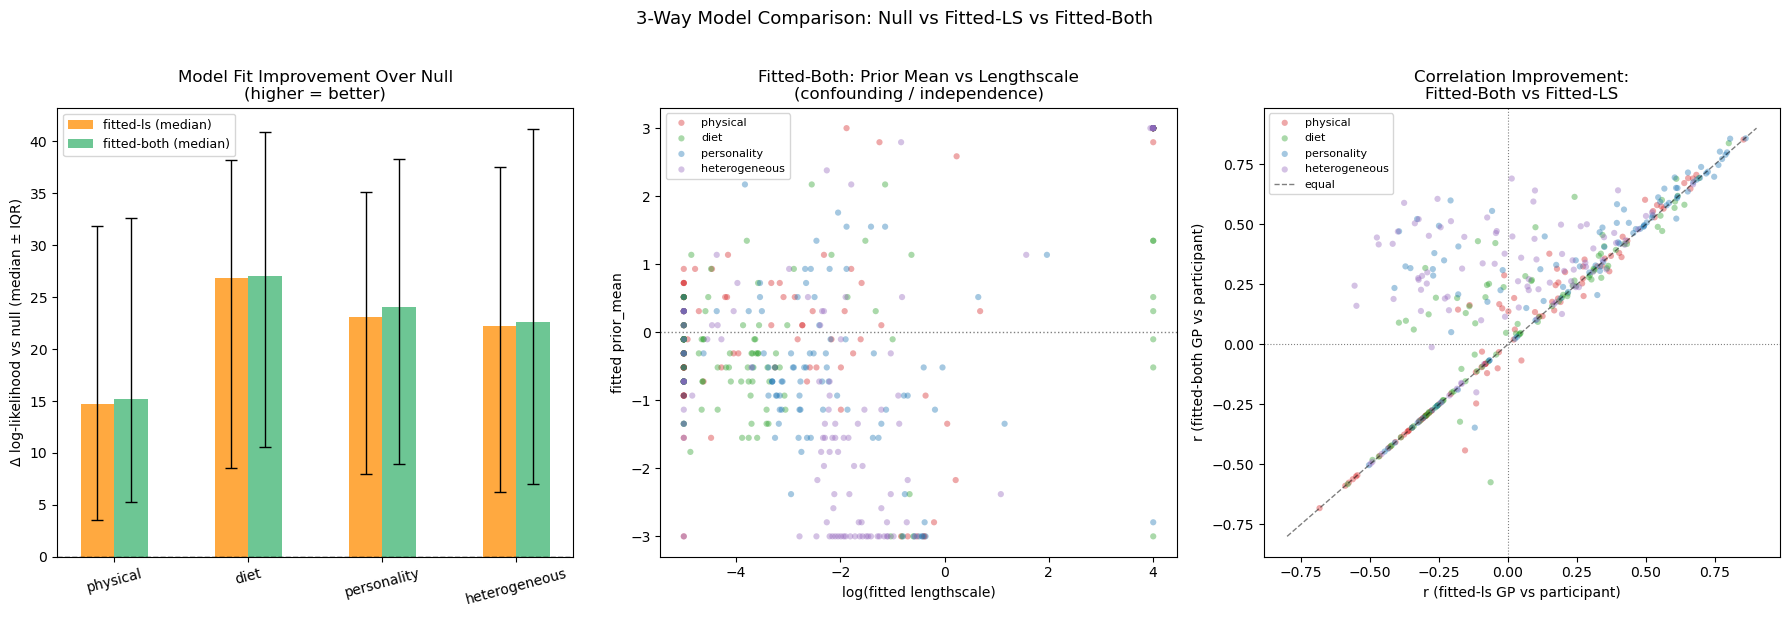

In [25]:
# ── 3-way model comparison visualization ──────────────────────────────────
# Panel 1: Δ log-likelihood vs null for all 3 models (boxplot by condition)
# Panel 2: fitted_both_pm vs fitted_both_ls scatter — shows parameter interaction
# Panel 3: r_both vs r_fitted scatter — does adding prior_mean improve correlation?

cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
               'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}
cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: Δ log-likelihood vs null, all 3 models ───────────────────────
ax = axes[0]
n_cond = len(cond_order)
x_base = np.arange(n_cond)
width  = 0.25

for k, (key, label, color) in enumerate([
    ('delta_ll',      'fitted-ls',   'darkorange'),
    ('delta_ll_both', 'fitted-both', 'mediumseagreen'),
]):
    medians = [np.median([r[key] for r in results if r['condition'] == c]) for c in cond_order]
    q25     = [np.percentile([r[key] for r in results if r['condition'] == c], 25) for c in cond_order]
    q75     = [np.percentile([r[key] for r in results if r['condition'] == c], 75) for c in cond_order]
    x = x_base + (k - 0.5) * width
    ax.bar(x, medians, width, label=f'{label} (median)', color=color, alpha=0.75)
    ax.errorbar(x, medians,
                yerr=[np.array(medians) - np.array(q25),
                      np.array(q75)     - np.array(medians)],
                fmt='none', color='black', capsize=4, linewidth=1)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x_base)
ax.set_xticklabels(cond_order, rotation=15)
ax.set_ylabel('Δ log-likelihood vs null (median ± IQR)')
ax.set_title('Model Fit Improvement Over Null\n(higher = better)')
ax.legend(fontsize=9)

# ── Panel 2: fitted_both_pm vs fitted_both_ls ─────────────────────────────
ax = axes[1]
for cond in cond_order:
    cr = [r for r in results if r['condition'] == cond]
    ls_vals = [r['fitted_both_ls'] for r in cr]
    pm_vals = [r['fitted_both_pm'] for r in cr]
    ax.scatter(np.log(ls_vals), pm_vals, label=cond, color=cond_colors[cond],
               alpha=0.4, s=20, edgecolors='none')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('log(fitted lengthscale)')
ax.set_ylabel('fitted prior_mean')
ax.set_title('Fitted-Both: Prior Mean vs Lengthscale\n(confounding / independence)')
ax.legend(fontsize=8)

# ── Panel 3: r_both vs r_fitted ───────────────────────────────────────────
ax = axes[2]
for cond in cond_order:
    cr = [r for r in results if r['condition'] == cond
          and not np.isnan(r['r_fitted']) and not np.isnan(r['r_both'])]
    r_fit  = [r['r_fitted'] for r in cr]
    r_both = [r['r_both']   for r in cr]
    ax.scatter(r_fit, r_both, label=cond, color=cond_colors[cond],
               alpha=0.4, s=20, edgecolors='none')

lim = [-0.8, 0.9]
ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='equal')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('r (fitted-ls GP vs participant)')
ax.set_ylabel('r (fitted-both GP vs participant)')
ax.set_title('Correlation Improvement:\nFitted-Both vs Fitted-LS')
ax.legend(fontsize=8)

plt.suptitle('3-Way Model Comparison: Null vs Fitted-LS vs Fitted-Both', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/740941676.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=cond_order, patch_artist=True)


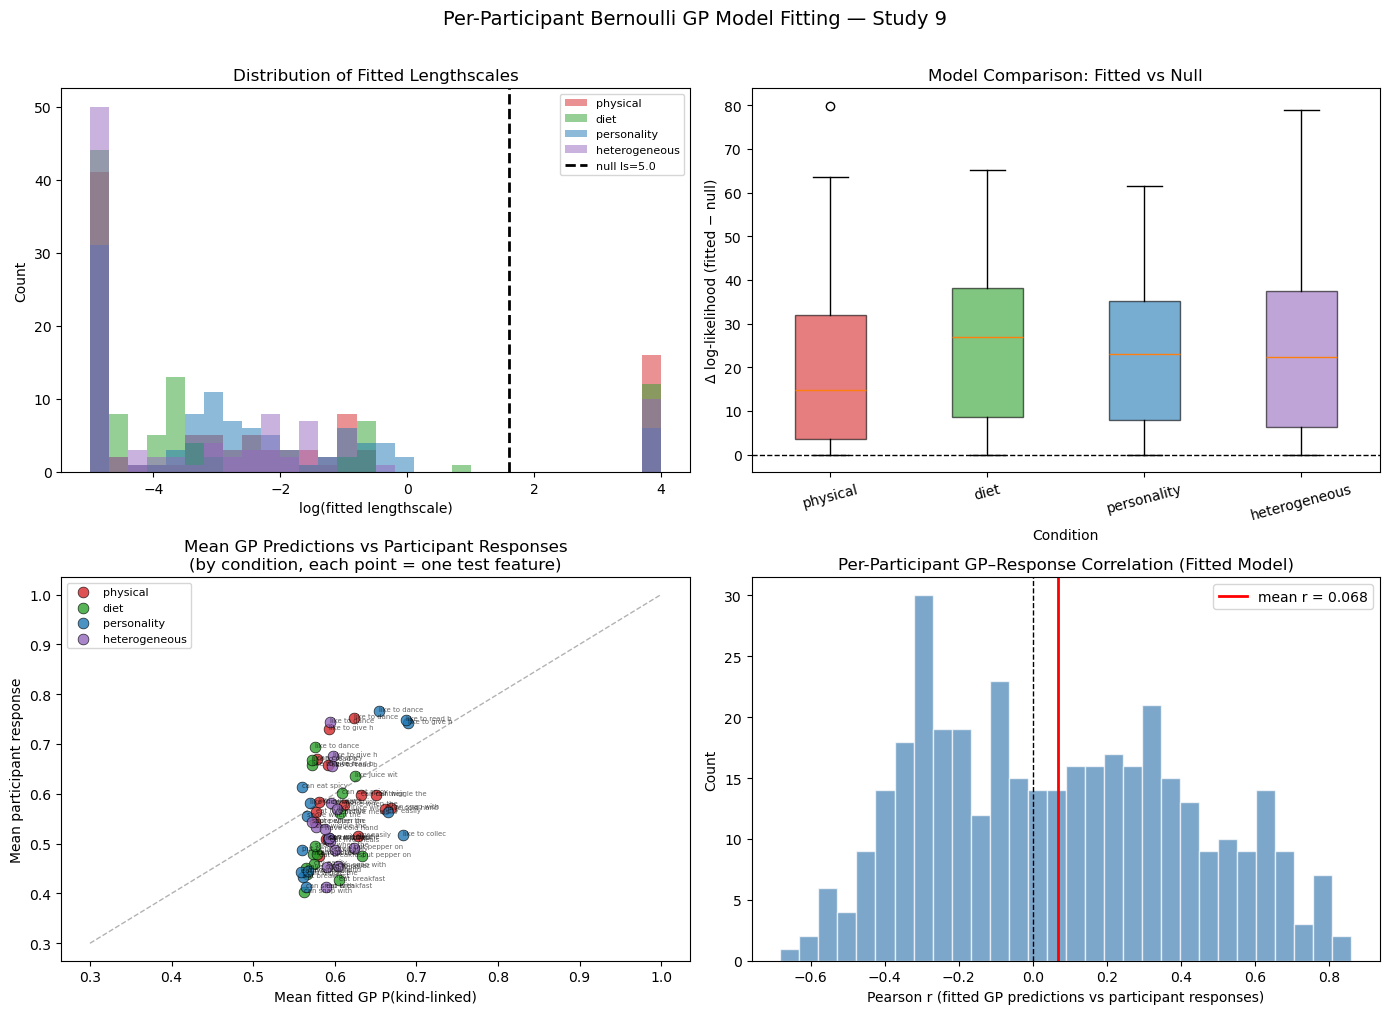

In [26]:
# ── 4-panel results visualization ─────────────────────────────────────────
cond_colors = {
    'physical':    'tab:red',
    'diet':        'tab:green',
    'personality': 'tab:blue',
    'heterogeneous': 'tab:purple',
}
cond_order = ['physical', 'diet', 'personality', 'heterogeneous']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Distribution of fitted lengthscales ──────────────────────────
ax = axes[0, 0]
for cond in cond_order:
    ls_vals = [r['fitted_ls'] for r in results if r['condition'] == cond]
    ax.hist(np.log(ls_vals), bins=30, alpha=0.5, label=cond, color=cond_colors[cond])
ax.axvline(x=np.log(NULL_LS), color='black', linestyle='--', linewidth=2,
           label=f'null ls={NULL_LS}')
ax.set_xlabel('log(fitted lengthscale)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Fitted Lengthscales')
ax.legend(fontsize=8)

# ── Panel 2: Delta log-likelihood (fitted − null) ─────────────────────────
ax = axes[0, 1]
data_by_cond = [[r['delta_ll'] for r in results if r['condition'] == c]
                for c in cond_order]
bp = ax.boxplot(data_by_cond, labels=cond_order, patch_artist=True)
for patch, cond in zip(bp['boxes'], cond_order):
    patch.set_facecolor(cond_colors[cond])
    patch.set_alpha(0.6)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Condition')
ax.set_ylabel('Δ log-likelihood (fitted − null)')
ax.set_title('Model Comparison: Fitted vs Null')
ax.tick_params(axis='x', rotation=15)

# ── Panel 3: Mean GP predictions vs mean participant responses ─────────────
ax = axes[1, 0]
for cond in cond_order:
    cr = [r for r in results if r['condition'] == cond]
    mean_preds     = np.mean([r['fitted_preds'] for r in cr], axis=0)
    mean_responses = np.mean([r['responses']    for r in cr], axis=0)
    ax.scatter(mean_preds, mean_responses, label=cond, color=cond_colors[cond],
               alpha=0.8, s=60, edgecolors='black', linewidths=0.5)
    for j, feat_name in enumerate(CSV_TO_FEATURE.values()):
        ax.annotate(feat_name[:14], (mean_preds[j], mean_responses[j]),
                    fontsize=5, alpha=0.6)
lims = [0.3, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Mean fitted GP P(kind-linked)')
ax.set_ylabel('Mean participant response')
ax.set_title('Mean GP Predictions vs Participant Responses\n(by condition, each point = one test feature)')
ax.legend(fontsize=8)

# ── Panel 4: Per-participant correlation distribution ─────────────────────
ax = axes[1, 1]
r_all = [r['r_fitted'] for r in results if not np.isnan(r['r_fitted'])]
ax.hist(r_all, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.axvline(x=np.mean(r_all), color='red', linestyle='-', linewidth=2,
           label=f'mean r = {np.mean(r_all):.3f}')
ax.set_xlabel('Pearson r (fitted GP predictions vs participant responses)')
ax.set_ylabel('Count')
ax.set_title('Per-Participant GP–Response Correlation (Fitted Model)')
ax.legend()

plt.suptitle('Per-Participant Bernoulli GP Model Fitting — Study 9', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

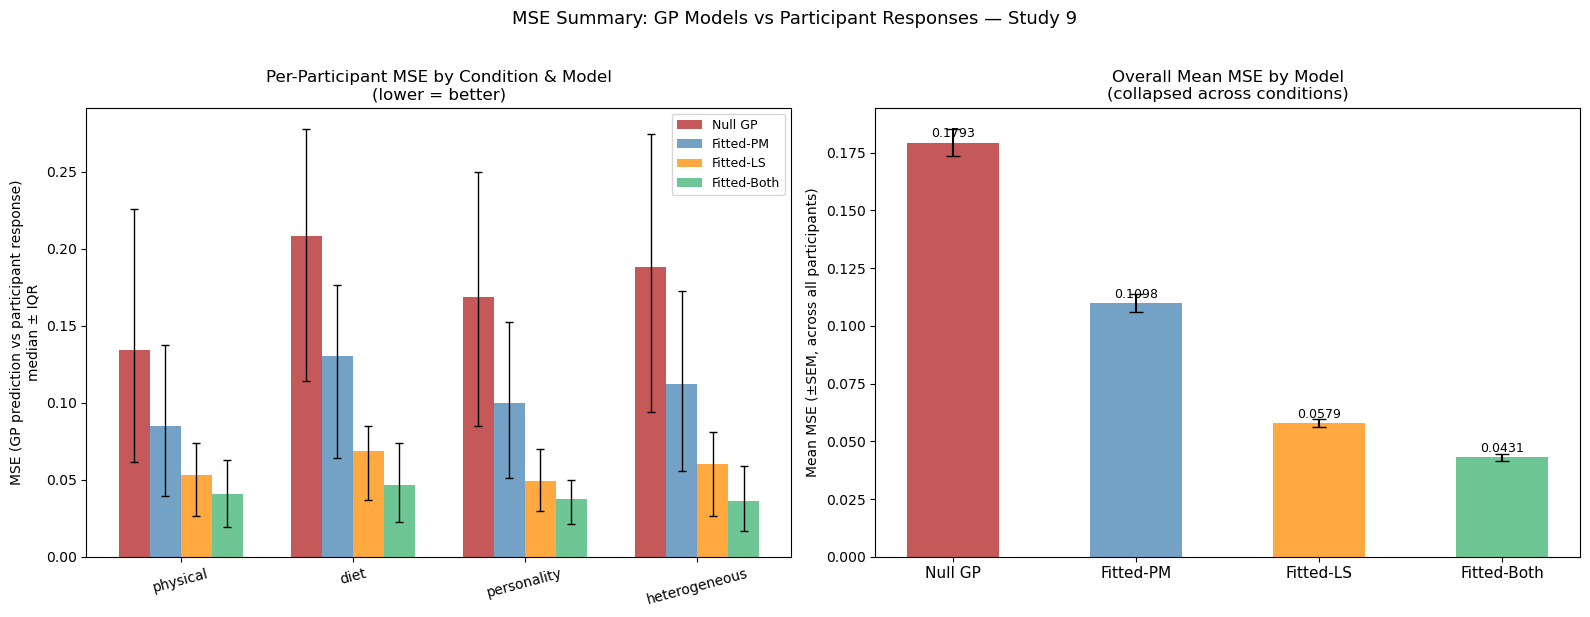


Condition         MSE_null    MSE_pm    MSE_ls  MSE_both  %imp_pm  %imp_ls  %imp_both
------------------------------------------------------------------------------------------
physical            0.1599    0.0969    0.0565    0.0434    39.4%    64.7%      72.9%
diet                0.1981    0.1222    0.0628    0.0483    38.3%    68.3%      75.6%
personality         0.1716    0.1042    0.0511    0.0373    39.3%    70.2%      78.2%
heterogeneous       0.1879    0.1158    0.0614    0.0435    38.3%    67.3%      76.9%
------------------------------------------------------------------------------------------
ALL                 0.1793    0.1098    0.0579    0.0431    38.8%    67.7%      76.0%


In [27]:
# ── MSE summary: all 4 models, by condition ───────────────────────────────
# MSE = mean((GP_prediction - participant_response)²) per participant,
# then averaged within condition.

cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
mse_keys    = ['mse_null', 'mse_pm', 'mse_ls', 'mse_both']
mse_labels  = ['Null GP', 'Fitted-PM', 'Fitted-LS', 'Fitted-Both']
mse_colors  = ['firebrick', 'steelblue', 'darkorange', 'mediumseagreen']

# Compute per-participant MSE for each model
for r in results:
    r['mse_null'] = float(np.mean((r['null_preds']        - r['responses']) ** 2))
    r['mse_ls']   = float(np.mean((r['fitted_preds']       - r['responses']) ** 2))
    r['mse_pm']   = float(np.mean((r['fitted_pm_preds']    - r['responses']) ** 2))
    r['mse_both'] = float(np.mean((r['fitted_both_preds']  - r['responses']) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Grouped bar chart by condition ───────────────────────────────
ax = axes[0]
n_models = len(mse_keys)
n_conds  = len(cond_order)
x_base   = np.arange(n_conds)
width    = 0.18

for k, (key, label, color) in enumerate(zip(mse_keys, mse_labels, mse_colors)):
    vals_by_cond = [[r[key] for r in results if r['condition'] == c] for c in cond_order]
    medians = [np.median(v) for v in vals_by_cond]
    q25     = [np.percentile(v, 25) for v in vals_by_cond]
    q75     = [np.percentile(v, 75) for v in vals_by_cond]
    x = x_base + (k - 1.5) * width
    ax.bar(x, medians, width, label=label, color=color, alpha=0.75)
    ax.errorbar(x, medians,
                yerr=[np.array(medians) - np.array(q25),
                      np.array(q75)     - np.array(medians)],
                fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xticks(x_base)
ax.set_xticklabels(cond_order, rotation=15)
ax.set_ylabel('MSE (GP prediction vs participant response)\nmedian ± IQR')
ax.set_title('Per-Participant MSE by Condition & Model\n(lower = better)')
ax.legend(fontsize=9)

# ── Panel 2: Mean MSE collapsed across conditions ─────────────────────────
ax = axes[1]
x_pos = np.arange(n_models)
means = [np.mean([r[key] for r in results]) for key in mse_keys]
sems  = [np.std([r[key] for r in results]) / np.sqrt(len(results)) for key in mse_keys]
bars  = ax.bar(x_pos, means, color=mse_colors, alpha=0.75, width=0.5)
ax.errorbar(x_pos, means, yerr=sems, fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.001,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(mse_labels, fontsize=11)
ax.set_ylabel('Mean MSE (±SEM, across all participants)')
ax.set_title('Overall Mean MSE by Model\n(collapsed across conditions)')

plt.suptitle('MSE Summary: GP Models vs Participant Responses — Study 9', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Print table ───────────────────────────────────────────────────────────
print(f"\n{'Condition':<16} {'MSE_null':>9} {'MSE_pm':>9} {'MSE_ls':>9} {'MSE_both':>9}  {'%imp_pm':>7}  {'%imp_ls':>7}  {'%imp_both':>9}")
print('-' * 90)
for cond in cond_order:
    cr = [r for r in results if r['condition'] == cond]
    mn = np.mean([r['mse_null'] for r in cr])
    ml = np.mean([r['mse_ls']   for r in cr])
    mp = np.mean([r['mse_pm']   for r in cr])
    mb = np.mean([r['mse_both'] for r in cr])
    print(f"{cond:<16} {mn:>9.4f} {mp:>9.4f} {ml:>9.4f} {mb:>9.4f}  {(mn-mp)/mn*100:>6.1f}%  {(mn-ml)/mn*100:>6.1f}%  {(mn-mb)/mn*100:>8.1f}%")
mn_all = np.mean([r['mse_null'] for r in results])
ml_all = np.mean([r['mse_ls']   for r in results])
mp_all = np.mean([r['mse_pm']   for r in results])
mb_all = np.mean([r['mse_both'] for r in results])
print('-' * 90)
print(f"{'ALL':<16} {mn_all:>9.4f} {mp_all:>9.4f} {ml_all:>9.4f} {mb_all:>9.4f}  {(mn_all-mp_all)/mn_all*100:>6.1f}%  {(mn_all-ml_all)/mn_all*100:>6.1f}%  {(mn_all-mb_all)/mn_all*100:>8.1f}%")


# Visualize Participant Belief Predictions

In [28]:
# ── Per-participant visualizer ────────────────────────────────────────────
#
# 5-panel figure (left → right):
#   1. Null GP heatmap         (ls=5.0,        pm=0 fixed)
#   2. Fitted-LS GP heatmap    (ls fit,         pm=0 fixed)
#   3. Fitted-PM GP heatmap    (ls=5.0 fixed,   pm fit)
#   4. Fitted-Both GP heatmap  (ls + pm fit)
#   5. Bar chart: participant | fitted-pm | fitted-ls | fitted-both | null
#
# Heatmap background = GP predicted P(kind-linked)
# Test feature squares  = colored by PARTICIPANT RESPONSE (for direct comparison)
# Panel titles show MSE between GP test-point predictions and participant responses

# Precompute category ordering for bar chart (built once, reused per call)
_feat_to_cat   = df.set_index('feature')['category'].to_dict()
_cat_order     = ['diet_preferences', 'personality_behaviors', 'physical']
_cat_colors    = {'diet_preferences': '#d4edda', 'personality_behaviors': '#cce5ff', 'physical': '#f8d7da'}
_cat_labels    = {'diet_preferences': 'diet', 'personality_behaviors': 'personality', 'physical': 'physical'}

_ordered_cols  = []
_cat_spans     = []
for _cat in _cat_order:
    _cols = [c for c in TEST_COLS if _feat_to_cat.get(CSV_TO_FEATURE[c]) == _cat]
    _cat_spans.append((len(_ordered_cols), len(_ordered_cols) + len(_cols), _cat))
    _ordered_cols.extend(_cols)
_short_names = [CSV_TO_FEATURE[c][:14] for c in _ordered_cols]
_ordered_idx = [TEST_COLS.index(c) for c in _ordered_cols]


def _get_train_info(condition):
    if condition == 'physical':
        mask = (df['category'] == 'physical') & (df['split'] == 'train')
    elif condition == 'diet':
        mask = (df['category'] == 'diet_preferences') & (df['split'] == 'train')
    elif condition == 'personality':
        mask = (df['category'] == 'personality_behaviors') & (df['split'] == 'train')
    elif condition == 'heterogeneous':
        mask = (df['in_heterogenous'] == True) & (df['split'] == 'train')
    else:
        raise ValueError(f"Unknown condition: {condition!r}")
    train_df = df[mask]
    return jnp.array(train_df[['x_2d', 'y_2d']].values), train_df['feature'].tolist()


def _draw_gp_panel(ax, X_tr, y_tr, grid_coords, xx, yy, X_test_arr,
                   kernel_params, prior_mean_val, responses, gp_test_preds,
                   train_names, title):
    """GP heatmap (background) + train circles + test squares colored by participant responses."""
    probs_grid, _, _ = gp.laplace_predict(
        X_tr, y_tr, grid_coords, kernel_params,
        kernel_name='rbf_2d_ard', prior_mean=prior_mean_val
    )
    probs_grid = np.array(probs_grid).reshape(xx.shape)
    mse = float(np.mean((np.array(gp_test_preds) - np.array(responses)) ** 2))

    im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='RdYlGn',
                     alpha=0.75, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='GP P(kind-linked)', fraction=0.046, pad=0.04)

    ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
               c='steelblue', s=70, edgecolors='black', linewidths=1.5,
               zorder=5, label='train (kind-linked)')
    for j, name in enumerate(train_names):
        ax.annotate(name[:12], (float(X_tr[j, 0]), float(X_tr[j, 1])),
                    fontsize=4.5, alpha=0.75, xytext=(3, 3), textcoords='offset points')

    sc = ax.scatter(np.array(X_test_arr)[:, 0], np.array(X_test_arr)[:, 1],
                    c=responses, cmap='RdYlGn', vmin=0, vmax=1,
                    s=130, marker='s', edgecolors='black', linewidths=1, zorder=6,
                    label='test (participant)')
    plt.colorbar(sc, ax=ax, label='Participant response', fraction=0.046, pad=0.12)

    ax.set_xlim(-0.5, 0.45);  ax.set_ylim(-0.45, 0.35)
    ax.set_xlabel('Embedding Dim 1');  ax.set_ylabel('Embedding Dim 2')
    ax.set_title(f'{title}\nMSE={mse:.4f}', fontsize=9)
    ax.legend(fontsize=6, loc='upper right')


def plot_participant(i, grid_resolution=50):
    """
    5-panel visualizer for participant i.
    Panels 1-4: heatmaps for null / fitted-ls / fitted-pm / fitted-both
    Panel 5:    bar chart comparing all 4 models + participant responses
    """
    r                 = results[i]
    cond              = r['condition']
    responses         = r['responses']
    fitted_ls         = r['fitted_ls']
    fitted_preds      = r['fitted_preds']
    fitted_pm_pm      = r['fitted_pm_pm']
    fitted_pm_preds   = r['fitted_pm_preds']
    fitted_both_ls    = r['fitted_both_ls']
    fitted_both_pm    = r['fitted_both_pm']
    fitted_both_preds = r['fitted_both_preds']
    null_preds        = r['null_preds']
    delta_ll          = r['delta_ll']
    delta_ll_pm       = r['delta_ll_pm']
    delta_ll_both     = r['delta_ll_both']
    r_val             = r['r_fitted']
    r_pm_val          = r['r_pm']
    r_both_val        = r['r_both']

    X_tr, y_tr = get_condition_train(cond)
    _, train_names = _get_train_info(cond)

    xx, yy = np.meshgrid(
        np.linspace(-0.5, 0.45, grid_resolution),
        np.linspace(-0.45, 0.35, grid_resolution)
    )
    grid_coords = jnp.array(np.stack([xx.ravel(), yy.ravel()], axis=1))

    null_kp        = jnp.array([GP_SIGMA, NULL_LS,        NULL_LS       ])
    fitted_kp      = jnp.array([GP_SIGMA, fitted_ls,      fitted_ls     ])
    fitted_pm_kp   = jnp.array([GP_SIGMA, NULL_LS,        NULL_LS       ])  # same ls as null
    fitted_both_kp = jnp.array([GP_SIGMA, fitted_both_ls, fitted_both_ls])

    fig, axes = plt.subplots(1, 5, figsize=(32, 6))
    ax1, ax2, ax3, ax4, ax5 = axes

    _draw_gp_panel(ax1, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   null_kp, PRIOR_MEAN, responses, null_preds, train_names,
                   title=f'Null GP  (ls={NULL_LS},  pm=0)')

    _draw_gp_panel(ax3, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   fitted_kp, PRIOR_MEAN, responses, fitted_preds, train_names,
                   title=f'Fitted-LS GP  (ls={fitted_ls:.3f},  pm=0)')

    _draw_gp_panel(ax2, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   fitted_pm_kp, fitted_pm_pm, responses, fitted_pm_preds, train_names,
                   title=f'Fitted-PM GP  (ls={NULL_LS},  pm={fitted_pm_pm:.2f})')

    _draw_gp_panel(ax4, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   fitted_both_kp, fitted_both_pm, responses, fitted_both_preds, train_names,
                   title=f'Fitted-Both GP  (ls={fitted_both_ls:.3f},  pm={fitted_both_pm:.2f})')

    # ── Bar chart ──────────────────────────────────────────────────────────
    x_pos = np.arange(len(_ordered_cols))
    width = 0.16

    resp_ord        = responses[_ordered_idx]
    fitted_ord      = fitted_preds[_ordered_idx]
    fitted_pm_ord   = fitted_pm_preds[_ordered_idx]
    fitted_both_ord = fitted_both_preds[_ordered_idx]
    null_ord        = null_preds[_ordered_idx]

    for start, end, cat in _cat_spans:
        ax5.axvspan(start - 0.5, end - 0.5, alpha=0.12, color=_cat_colors[cat], zorder=0)
        ax5.text((start + end) / 2 - 0.5, 0.97, _cat_labels[cat],
                 ha='center', va='top', fontsize=8, color='gray',
                 transform=ax5.get_xaxis_transform())

    ax5.bar(x_pos - 2*width, resp_ord,        width, label='participant',      color='steelblue',      alpha=0.85)
    ax5.bar(x_pos - 1*width, fitted_pm_ord,   width, label='fitted-pm GP',     color='cornflowerblue', alpha=0.85)
    ax5.bar(x_pos + 0*width, fitted_ord,       width, label='fitted-ls GP',     color='darkorange',     alpha=0.85)
    ax5.bar(x_pos + 1*width, fitted_both_ord,  width, label='fitted-both GP',   color='mediumseagreen', alpha=0.85)
    ax5.bar(x_pos + 2*width, null_ord,         width, label='null GP',
            color='white', edgecolor='firebrick', linewidth=1.2, alpha=0.9)

    for start, _, _ in _cat_spans[1:]:
        ax5.axvline(x=start - 0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

    ax5.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(_short_names, rotation=45, ha='right', fontsize=7)
    ax5.set_ylim(0, 1.05)
    ax5.set_ylabel('P(kind-linked)')
    ax5.legend(fontsize=7, loc='upper right')

    def fmt(v): return f'{v:.2f}' if not np.isnan(v) else 'n/a'
    ax5.set_title(
        f'Participant {i}  |  condition: {cond}\n'
        f'r: ls={fmt(r_val)}, pm={fmt(r_pm_val)}, both={fmt(r_both_val)}\n'
        f'Δll: ls={delta_ll:.1f}, pm={delta_ll_pm:.1f}, both={delta_ll_both:.1f}',
        fontsize=9
    )

    plt.suptitle(f'Study 9 — Participant {i} ({cond})', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


print("plot_participant(i) defined. Call with any index 0 –", len(results) - 1)


plot_participant(i) defined. Call with any index 0 – 401


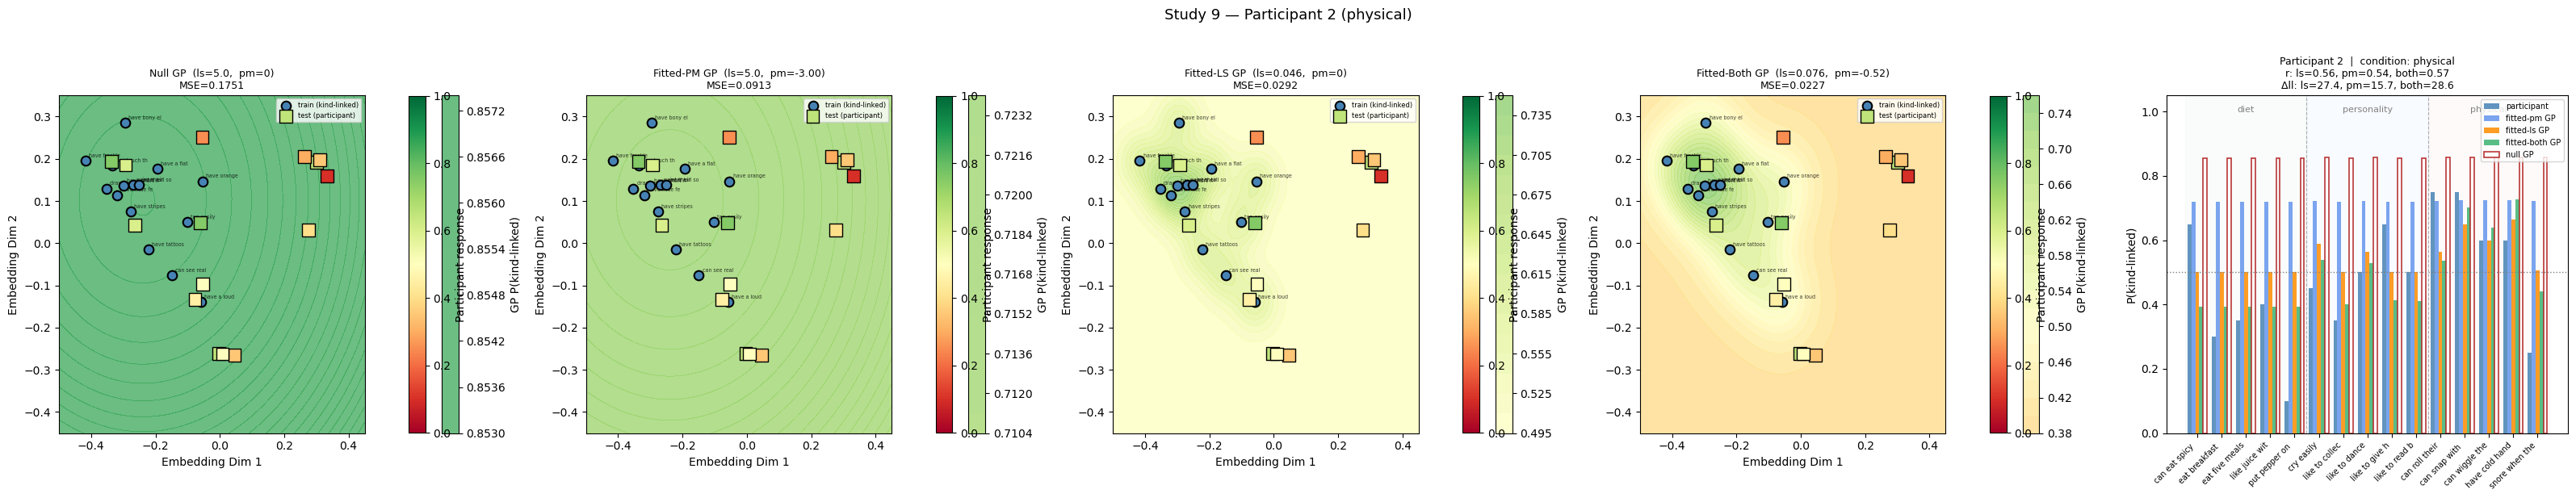

In [29]:
# ── Example: plot a specific participant ─────────────────────────────────
# Change i to any index 0 – len(results)-1

plot_participant(2)

total log likelihood for each model w/ each participants (can sum MLE) and do log likelihood ratio test b/c nested models (compare fitting only prior mean + mean and length scale)

In [30]:

# ── Summary visualizer: all 4 conditions ─────────────────────────────────
#
# Layout: 2×2 grid, one panel per condition
#   Background heatmap = GP P(kind-linked) using median fitted-both hyperparams
#   Train features     = filled circles (steelblue)
#   Test features      = transparent open circles (no fill) — just marking location
#
# Note: heatmap encodes coherence (GP belief about kind-linking);
#       test feature circles are just position markers, not colored by response.

def plot_all_conditions_summary(grid_resolution=50):
    """
    2×2 summary figure, one panel per condition (physical, diet, personality, heterogeneous).
    Each panel: GP heatmap (fitted-both) using condition-median hyperparams.
    Train features = filled blue circles; test features = open transparent circles.
    """
    cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
    cond_labels = {'physical': 'Physical', 'diet': 'Diet',
                   'personality': 'Personality', 'heterogeneous': 'Heterogeneous'}

    xx, yy = np.meshgrid(
        np.linspace(-0.5, 0.45, grid_resolution),
        np.linspace(-0.45, 0.35, grid_resolution)
    )
    grid_coords = jnp.array(np.stack([xx.ravel(), yy.ravel()], axis=1))

    fig, axes = plt.subplots(2, 2, figsize=(13, 12))

    for idx, cond in enumerate(cond_order):
        ax  = axes[idx // 2, idx % 2]
        cr  = [r for r in results if r['condition'] == cond]
        n   = len(cr)

        # Median hyperparams for the heatmap
        med_ls = float(np.median([r['fitted_both_ls'] for r in cr]))
        med_pm = float(np.median([r['fitted_both_pm'] for r in cr]))
        kp     = jnp.array([GP_SIGMA, med_ls, med_ls])

        X_tr, y_tr     = get_condition_train(cond)
        _, train_names = _get_train_info(cond)

        # GP heatmap
        probs_grid, _, _ = gp.laplace_predict(
            X_tr, y_tr, grid_coords, kp,
            kernel_name='rbf_2d_ard', prior_mean=med_pm
        )
        probs_grid = np.array(probs_grid).reshape(xx.shape)

        im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='RdYlGn',
                         alpha=0.75, vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label='GP P(kind-linked)', fraction=0.046, pad=0.04)

        # Train features — filled circles
        ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
                   c='steelblue', s=70, edgecolors='black', linewidths=1.5,
                   zorder=5, label='train (kind-linked)')
        for j, name in enumerate(train_names):
            ax.annotate(name[:12], (float(X_tr[j, 0]), float(X_tr[j, 1])),
                        fontsize=4.5, alpha=0.75, xytext=(3, 3),
                        textcoords='offset points')

        # Test features — open transparent circles (position markers only)
        ax.scatter(np.array(X_test)[:, 0], np.array(X_test)[:, 1],
                   facecolors='none', edgecolors='black', linewidths=1.2,
                   s=80, alpha=0.5, zorder=6, label='test features')

        ax.set_xlim(-0.5, 0.45);  ax.set_ylim(-0.45, 0.35)
        ax.set_xlabel('Embedding Dim 1')
        ax.set_ylabel('Embedding Dim 2')
        ax.set_title(
            f'{cond_labels[cond]}  (n={n})\n'
            f'Fitted GP — median ls={med_ls:.3f}, pm={med_pm:.2f}',
            fontsize=10
        )
        ax.legend(fontsize=7, loc='upper right')

    plt.suptitle('Posterior over Coherence in Embedding Space', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


print("plot_all_conditions_summary() defined.")


plot_all_conditions_summary() defined.


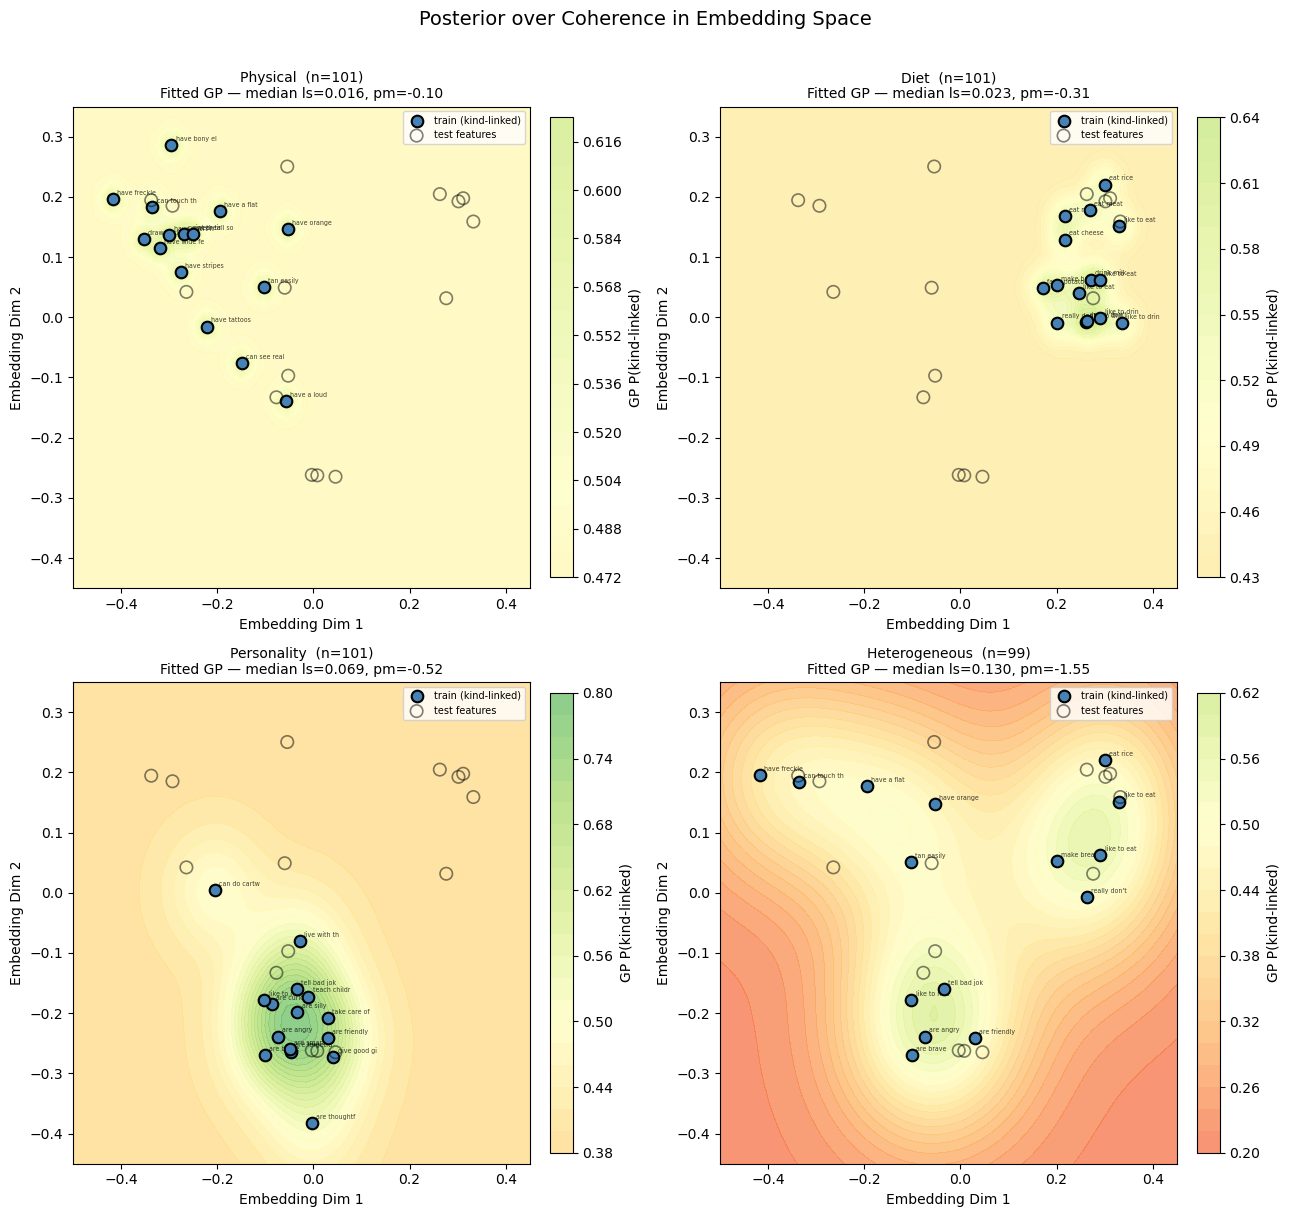

In [31]:
plot_all_conditions_summary()

if we want to explain variability between conditions, it's ok that some params are fit across all conditions (b/c they should be invariant across conditions) and the thing we do care about (lengthscale, generalization) is fit within participant which is also within condition

distribution of length scales under each condition ; change colorscale to be unipolar

fit prior mean first (across all)
then fit individual lengthscales per participant


then aggregate across conditions

shorter down the line; linking function

longer down the line;  
perhaps jointly optimizing betas for linking, by participant, population lvl, and by item (feature)

In [ ]:
# Per-participant coherence θ (mean GP P(kind-linked) across all test features)
# θ is a single category-wide coherence estimate ("probability any feature is kind-linked")

for r in results:
    r['theta_null']  = float(np.mean(r['null_preds']))
    r['theta_pm']    = float(np.mean(r['fitted_pm_preds']))
    r['theta_ls']    = float(np.mean(r['fitted_preds']))
    r['theta_both']  = float(np.mean(r['fitted_both_preds']))

# Summarize θ by condition
for model_key, label in [('theta_null','null'), ('theta_pm','fitted-pm'),
                          ('theta_ls','fitted-ls'), ('theta_both','fitted-both')]:
    print(f"\nθ ({label}):")
    for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
        vals = [r[model_key] for r in results if r['condition'] == cond]
        print(f"  {cond:<16}  mean={np.mean(vals):.3f}  std={np.std(vals):.3f}")



θ (null):
  physical          mean=0.856  std=0.000
  diet              mean=0.856  std=0.000
  personality       mean=0.856  std=0.000
  heterogeneous     mean=0.857  std=0.000

θ (fitted-pm):
  physical          mean=0.759  std=0.082
  diet              mean=0.748  std=0.063
  personality       mean=0.743  std=0.055
  heterogeneous     mean=0.748  std=0.066

θ (fitted-ls):
  physical          mean=0.609  std=0.136
  diet              mean=0.586  std=0.132
  personality       mean=0.605  std=0.118
  heterogeneous     mean=0.595  std=0.124

θ (fitted-both):
  physical          mean=0.589  std=0.203
  diet              mean=0.525  std=0.193
  personality       mean=0.553  std=0.174
  heterogeneous     mean=0.543  std=0.196


# Linking Function w/ Fitted Betas

In [110]:
from scipy.optimize import minimize
from scipy.stats import beta as beta_dist

def fit_beta_mixture(responses_j, weights):
    """
    Fit Beta mixture with fixed weights: r ~ p(z'=1)·Beta(a1,b1) + p(z'=0)·Beta(a2,b2)
    responses_j: (N,) in [0,1]; weights: (N,) in [0,1] — p(z'_j=1) per participant for feature j
    Returns: (alpha_kl, beta_kl, alpha_nkl, beta_nkl)
    """
    eps = 1e-6
    r   = np.clip(responses_j, eps, 1 - eps)
    th  = np.array(weights)

    def neg_ll(params):
        a1, b1, a2, b2 = params
        pdf1 = beta_dist.pdf(r, a1, b1)
        pdf2 = beta_dist.pdf(r, a2, b2)
        mixture = th * pdf1 + (1 - th) * pdf2
        return -np.sum(np.log(np.clip(mixture, 1e-300, None)))

    # Try multiple initializations to avoid local optima
    best = None
    for init in [(5, 1, 1, 5), (3, 1, 1, 3), (8, 2, 2, 5), (2, 2, 2, 2)]:
        res = minimize(neg_ll, x0=init, method='L-BFGS-B',
                       bounds=[(0.1, 50)] * 4)
        if best is None or res.fun < best.fun:
            best = res

    a1, b1, a2, b2 = best.x
    # Enforce labeling: alpha_kl = high-prevalence Beta (mean > 0.5)
    mean1 = a1 / (a1 + b1)
    mean2 = a2 / (a2 + b2)
    if mean1 >= mean2:
        return dict(alpha_kl=a1, beta_kl=b1, alpha_nkl=a2, beta_nkl=b2)
    else:
        return dict(alpha_kl=a2, beta_kl=b2, alpha_nkl=a1, beta_nkl=b1)


# Fit using per-feature p(z'_j=1) weights from fitted-both GP
# w_j[i] = GP's predicted P(kind-linked) for feature j, participant i
feature_betas = {}   # feature_name -> {alpha_kl, beta_kl, alpha_nkl, beta_nkl}

for j, col in enumerate(TEST_COLS):
    feat   = CSV_TO_FEATURE[col]
    resp_j = np.array([r['responses'][j]          for r in results])   # (N,) prevalence ratings
    w_j    = np.array([r['fitted_both_preds'][j]   for r in results])   # (N,) p(z'_j=1) per participant
    feature_betas[feat] = fit_beta_mixture(resp_j, w_j)
    params = feature_betas[feat]
    mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
    mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
    print(f"{feat:<30}  kl: Beta({params['alpha_kl']:.2f},{params['beta_kl']:.2f}) mean={mean_kl:.2f}  "
          f"nkl: Beta({params['alpha_nkl']:.2f},{params['beta_nkl']:.2f}) mean={mean_nkl:.2f}")


can eat spicy food              kl: Beta(0.46,0.17) mean=0.73  nkl: Beta(3.13,2.92) mean=0.52
eat breakfast very late         kl: Beta(0.57,0.27) mean=0.68  nkl: Beta(2.53,6.22) mean=0.29
eat five meals a day            kl: Beta(0.50,0.19) mean=0.72  nkl: Beta(1.27,2.29) mean=0.36
like juice with pulp            kl: Beta(0.47,0.18) mean=0.72  nkl: Beta(4.01,4.17) mean=0.49
put pepper on all their foods   kl: Beta(0.48,0.22) mean=0.69  nkl: Beta(1.49,2.67) mean=0.36
cry easily                      kl: Beta(0.62,0.28) mean=0.69  nkl: Beta(2.61,4.56) mean=0.36
like to collect rocks           kl: Beta(0.52,0.22) mean=0.71  nkl: Beta(1.33,2.91) mean=0.31
like to dance                   kl: Beta(0.94,0.16) mean=0.85  nkl: Beta(5.02,2.83) mean=0.64
like to give high-fives         kl: Beta(0.58,0.15) mean=0.79  nkl: Beta(3.67,2.39) mean=0.61
like to read books              kl: Beta(0.63,0.17) mean=0.79  nkl: Beta(4.31,2.95) mean=0.59
can roll their tongue           kl: Beta(0.57,0.20) mean=0.7

mean_kl > mean_nkl: 15/15 features

feature                          mean_kl  mean_nkl       gap     w_std
----------------------------------------------------------------------
can eat spicy food                 0.734     0.518    +0.216     0.201
eat breakfast very late            0.679     0.289    +0.389     0.202
eat five meals a day               0.723     0.356    +0.367     0.202
like juice with pulp               0.718     0.490    +0.228     0.199
put pepper on all their foods      0.687     0.358    +0.329     0.197
cry easily                         0.692     0.364    +0.328     0.199
like to collect rocks              0.708     0.313    +0.395     0.202
like to dance                      0.853     0.640    +0.213     0.202
like to give high-fives            0.791     0.606    +0.185     0.201
like to read books                 0.786     0.594    +0.193     0.201
can roll their tongue              0.743     0.352    +0.391     0.210
can snap with their toes           0.783 

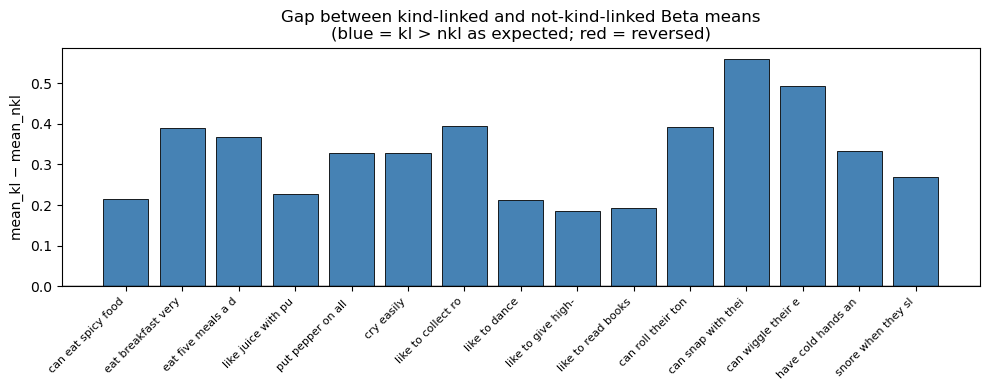

In [118]:
# ── Diagnostic: is mean_kl > mean_nkl per feature? ──────────────────────────
# If the mixture is capturing kind-linking, kl component should have higher
# mean prevalence than nkl. Gap near zero = mixture not doing useful work.

gaps = {}
for feat, params in feature_betas.items():
    mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
    mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
    gaps[feat] = mean_kl - mean_nkl

n_positive = sum(g > 0 for g in gaps.values())
print(f"mean_kl > mean_nkl: {n_positive}/{len(gaps)} features\n")
print(f"{'feature':<30}  {'mean_kl':>8}  {'mean_nkl':>8}  {'gap':>8}  {'w_std':>8}")
print("-" * 70)
for j, col in enumerate(TEST_COLS):
    feat = CSV_TO_FEATURE[col]
    p = feature_betas[feat]
    mean_kl  = p['alpha_kl']  / (p['alpha_kl']  + p['beta_kl'])
    mean_nkl = p['alpha_nkl'] / (p['alpha_nkl'] + p['beta_nkl'])
    w_std = float(np.std([r['fitted_both_preds'][j] for r in results]))
    flag = '  ✗' if gaps[feat] <= 0 else ''
    print(f"{feat:<30}  {mean_kl:>8.3f}  {mean_nkl:>8.3f}  {gaps[feat]:>+8.3f}  {w_std:>8.3f}{flag}")

# Bar chart of gaps
fig, ax = plt.subplots(figsize=(10, 4))
feat_list = list(gaps.keys())
gap_vals  = [gaps[f] for f in feat_list]
colors = ['steelblue' if g > 0 else 'tomato' for g in gap_vals]
ax.bar(range(len(feat_list)), gap_vals, color=colors, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(feat_list)))
ax.set_xticklabels([f[:18] for f in feat_list], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('mean_kl − mean_nkl')
ax.set_title('Gap between kind-linked and not-kind-linked Beta means\n(blue = kl > nkl as expected; red = reversed)')
plt.tight_layout()
plt.show()


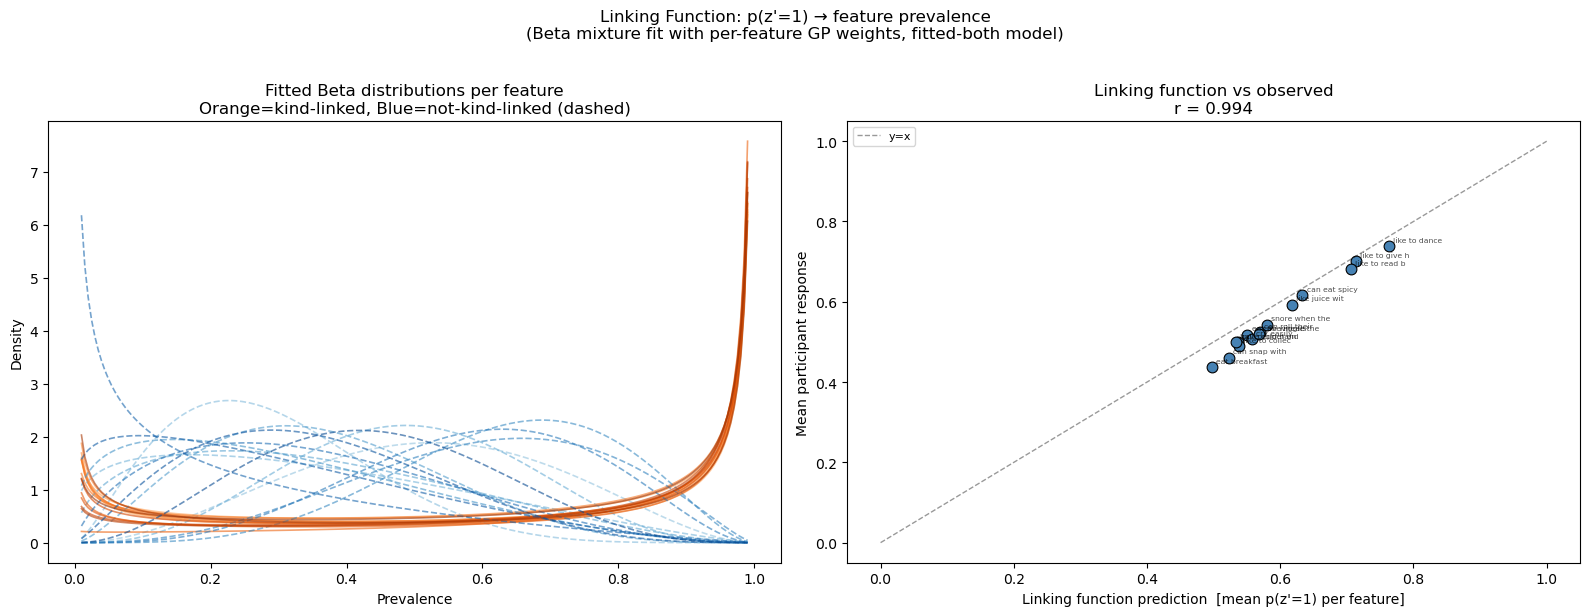

In [111]:
def linking_function(feature_pz1, feature_betas):
    """
    Predict E[prevalence] per feature given per-feature p(z'=1).
    feature_pz1:   dict {feature_name: p(z'_j=1)}  — GP-inferred P(kind-linked) per feature
    feature_betas: dict {feature_name: {alpha_kl, beta_kl, alpha_nkl, beta_nkl}}
    Returns dict: feature_name -> predicted mean prevalence
    """
    preds = {}
    for feat, params in feature_betas.items():
        pz1      = feature_pz1[feat]
        mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
        mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
        preds[feat] = pz1 * mean_kl + (1 - pz1) * mean_nkl
    return preds


# Mean p(z'_j=1) across participants for each feature j
mean_pz1 = {
    CSV_TO_FEATURE[col]: float(np.mean([r['fitted_both_preds'][j] for r in results]))
    for j, col in enumerate(TEST_COLS)
}

# ── Visualization: 2-panel overview ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Per-feature Beta distributions (kind-linked=orange, not-kl=blue)
ax = axes[0]
x_vals = np.linspace(0.01, 0.99, 200)
n_feats    = len(feature_betas)
colors_kl  = plt.cm.Oranges(np.linspace(0.4, 0.9, n_feats))
colors_nkl = plt.cm.Blues(np.linspace(0.4, 0.9, n_feats))
for k, (feat, params) in enumerate(feature_betas.items()):
    pdf_kl  = beta_dist.pdf(x_vals, params['alpha_kl'],  params['beta_kl'])
    pdf_nkl = beta_dist.pdf(x_vals, params['alpha_nkl'], params['beta_nkl'])
    ax.plot(x_vals, pdf_kl,  color=colors_kl[k],  alpha=0.6, lw=1.2)
    ax.plot(x_vals, pdf_nkl, color=colors_nkl[k], alpha=0.6, lw=1.2, linestyle='--')
ax.set_xlabel('Prevalence')
ax.set_ylabel('Density')
ax.set_title('Fitted Beta distributions per feature\nOrange=kind-linked, Blue=not-kind-linked (dashed)')

# Panel 2: Linking function prediction vs mean participant response per feature
ax = axes[1]
link_preds = linking_function(mean_pz1, feature_betas)
mean_responses = {CSV_TO_FEATURE[col]: float(np.mean([r['responses'][j] for r in results]))
                  for j, col in enumerate(TEST_COLS)}

feat_list   = list(link_preds.keys())
pred_vals   = [link_preds[f]     for f in feat_list]
actual_vals = [mean_responses[f] for f in feat_list]

ax.scatter(pred_vals, actual_vals, s=60, color='steelblue', edgecolors='black', linewidths=0.8)
for f, p, a in zip(feat_list, pred_vals, actual_vals):
    ax.annotate(f[:14], (p, a), fontsize=5.5, alpha=0.7, xytext=(3, 3), textcoords='offset points')
lo, hi = 0, 1
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.4, label='y=x')
r_link, _ = pearsonr(pred_vals, actual_vals)
ax.set_xlabel('Linking function prediction  [mean p(z\'=1) per feature]')
ax.set_ylabel('Mean participant response')
ax.set_title(f'Linking function vs observed\nr = {r_link:.3f}')
ax.legend(fontsize=8)

plt.suptitle(
    'Linking Function: p(z\'=1) → feature prevalence\n'
    '(Beta mixture fit with per-feature GP weights, fitted-both model)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


  LOO fold 1/402...
  LOO fold 21/402...
  LOO fold 41/402...
  LOO fold 61/402...
  LOO fold 81/402...
  LOO fold 101/402...
  LOO fold 121/402...
  LOO fold 141/402...
  LOO fold 161/402...
  LOO fold 181/402...
  LOO fold 201/402...
  LOO fold 221/402...
  LOO fold 241/402...
  LOO fold 261/402...
  LOO fold 281/402...
  LOO fold 301/402...
  LOO fold 321/402...
  LOO fold 341/402...
  LOO fold 361/402...
  LOO fold 381/402...
  LOO fold 401/402...
LOO-CV complete.

In-sample r (feature-level means):  0.994
LOO-CV r    (feature-level means):  0.994
LOO-CV r    (per-participant mean):  0.467  median=0.508  std=0.270

  physical          mean r=0.449  median=0.466  n=90
  diet              mean r=0.440  median=0.498  n=97
  personality       mean r=0.528  median=0.584  n=97
  heterogeneous     mean r=0.448  median=0.504  n=93


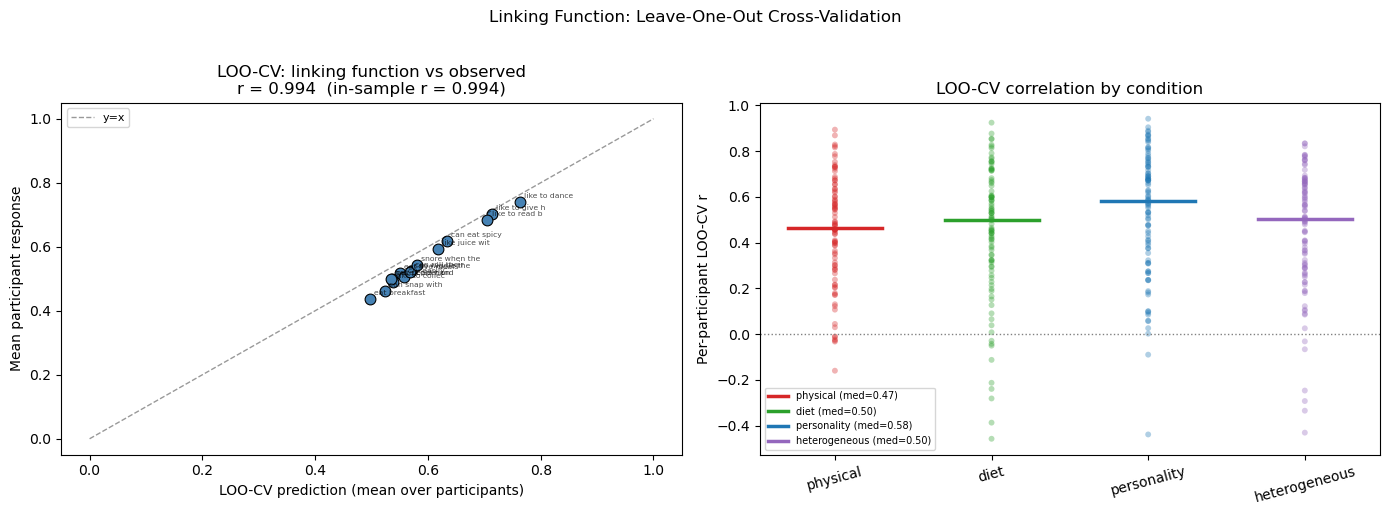

In [119]:
# ── Leave-one-out cross-validation for the linking function ─────────────────
# For each held-out participant i:
#   1. Fit Beta params on all other participants (using their per-feature GP weights)
#   2. Predict held-out participant's responses using their own GP weights + held-out Beta params
#   3. Correlate predicted vs actual across 15 features
# Note: uses 2 restarts per feature fit to keep runtime reasonable.

def fit_beta_mixture_fast(responses_j, weights):
    """Same as fit_beta_mixture but with 2 restarts for speed in LOO loop."""
    eps = 1e-6
    r   = np.clip(responses_j, eps, 1 - eps)
    th  = np.array(weights)
    def neg_ll(params):
        a1, b1, a2, b2 = params
        mixture = th * beta_dist.pdf(r, a1, b1) + (1 - th) * beta_dist.pdf(r, a2, b2)
        return -np.sum(np.log(np.clip(mixture, 1e-300, None)))
    best = None
    for init in [(5, 1, 1, 5), (2, 2, 2, 2)]:
        res = minimize(neg_ll, x0=init, method='L-BFGS-B', bounds=[(0.1, 50)] * 4)
        if best is None or res.fun < best.fun:
            best = res
    a1, b1, a2, b2 = best.x
    if a1/(a1+b1) >= a2/(a2+b2):
        return dict(alpha_kl=a1, beta_kl=b1, alpha_nkl=a2, beta_nkl=b2)
    else:
        return dict(alpha_kl=a2, beta_kl=b2, alpha_nkl=a1, beta_nkl=b1)


cv_results = []
n = len(results)
for i_out in range(n):
    if i_out % 20 == 0:
        print(f"  LOO fold {i_out+1}/{n}...")
    train = [r for k, r in enumerate(results) if k != i_out]
    r_out = results[i_out]

    # Fit Beta params on training participants
    fb_cv = {}
    for j, col in enumerate(TEST_COLS):
        feat  = CSV_TO_FEATURE[col]
        resp_j = np.array([r['responses'][j]          for r in train])
        w_j    = np.array([r['fitted_both_preds'][j]   for r in train])
        fb_cv[feat] = fit_beta_mixture_fast(resp_j, w_j)

    # Predict held-out participant
    preds_cv, actual_cv = [], []
    for j, col in enumerate(TEST_COLS):
        feat = CSV_TO_FEATURE[col]
        pz1  = float(r_out['fitted_both_preds'][j])
        p    = fb_cv[feat]
        mean_kl  = p['alpha_kl']  / (p['alpha_kl']  + p['beta_kl'])
        mean_nkl = p['alpha_nkl'] / (p['alpha_nkl'] + p['beta_nkl'])
        preds_cv.append(pz1 * mean_kl + (1 - pz1) * mean_nkl)
        actual_cv.append(float(r_out['responses'][j]))

    r_cv = pearsonr(preds_cv, actual_cv)[0] \
           if np.std(preds_cv) > 1e-6 and np.std(actual_cv) > 1e-6 else np.nan
    cv_results.append(dict(condition=r_out['condition'], r_cv=r_cv,
                           preds=preds_cv, actual=actual_cv))

print("LOO-CV complete.")

# ── Summary ───────────────────────────────────────────────────────────────────
r_insample = pearsonr(
    [link_preds[f]     for f in feat_list],
    [mean_responses[f] for f in feat_list]
)[0]

# LOO: aggregate predicted/actual across all participants then correlate at feature level
all_preds_cv   = np.zeros(len(TEST_COLS))
all_actual_cv  = np.zeros(len(TEST_COLS))
for res_cv in cv_results:
    all_preds_cv  += np.array(res_cv['preds'])
    all_actual_cv += np.array(res_cv['actual'])
all_preds_cv  /= n
all_actual_cv /= n
r_loo_agg = pearsonr(all_preds_cv, all_actual_cv)[0]

r_loo_per_ppt = [res_cv['r_cv'] for res_cv in cv_results if not np.isnan(res_cv['r_cv'])]

print(f"\nIn-sample r (feature-level means):  {r_insample:.3f}")
print(f"LOO-CV r    (feature-level means):  {r_loo_agg:.3f}")
print(f"LOO-CV r    (per-participant mean):  {np.mean(r_loo_per_ppt):.3f}  "
      f"median={np.median(r_loo_per_ppt):.3f}  std={np.std(r_loo_per_ppt):.3f}")
print()
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    vals = [res_cv['r_cv'] for res_cv in cv_results
            if res_cv['condition'] == cond and not np.isnan(res_cv['r_cv'])]
    print(f"  {cond:<16}  mean r={np.mean(vals):.3f}  median={np.median(vals):.3f}  n={len(vals)}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: LOO feature-level scatter (mirrors Panel 2 of link-func-viz-03 but held-out)
ax = axes[0]
feat_order = [CSV_TO_FEATURE[col] for col in TEST_COLS]
ax.scatter(all_preds_cv, all_actual_cv, s=60, color='steelblue',
           edgecolors='black', linewidths=0.8)
for f, p, a in zip(feat_order, all_preds_cv, all_actual_cv):
    ax.annotate(f[:14], (p, a), fontsize=5.5, alpha=0.7, xytext=(3, 3),
                textcoords='offset points')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='y=x')
ax.set_xlabel('LOO-CV prediction (mean over participants)')
ax.set_ylabel('Mean participant response')
ax.set_title(f'LOO-CV: linking function vs observed\nr = {r_loo_agg:.3f}  (in-sample r = {r_insample:.3f})')
ax.legend(fontsize=8)

# Panel 2: Distribution of per-participant LOO correlations by condition
ax = axes[1]
cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
               'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}
cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
for k, cond in enumerate(cond_order):
    vals = [res_cv['r_cv'] for res_cv in cv_results
            if res_cv['condition'] == cond and not np.isnan(res_cv['r_cv'])]
    ax.scatter([k] * len(vals), vals, alpha=0.35, s=18,
               color=cond_colors[cond], edgecolors='none')
    ax.plot([k - 0.3, k + 0.3], [np.median(vals)] * 2,
            color=cond_colors[cond], lw=2.5, label=f'{cond} (med={np.median(vals):.2f})')
ax.axhline(0, color='gray', linestyle=':', lw=1)
ax.set_xticks(range(len(cond_order)))
ax.set_xticklabels(cond_order, rotation=15)
ax.set_ylabel('Per-participant LOO-CV r')
ax.set_title('LOO-CV correlation by condition')
ax.legend(fontsize=7)

plt.suptitle('Linking Function: Leave-One-Out Cross-Validation', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: LOO feature-level scatter (mirrors Panel 2 of link-func-viz-03 but held-out)
ax = axes[0]
feat_order = [CSV_TO_FEATURE[col] for col in TEST_COLS]
ax.scatter(all_preds_cv, all_actual_cv, s=60, color='steelblue',
           edgecolors='black', linewidths=0.8)
for f, p, a in zip(feat_order, all_preds_cv, all_actual_cv):
    ax.annotate(f[:14], (p, a), fontsize=5.5, alpha=0.7, xytext=(3, 3),
                textcoords='offset points')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='y=x')
ax.set_xlabel('LOO-CV prediction (mean over participants)')
ax.set_ylabel('Mean participant response')
ax.set_title(f'LOO-CV: linking function vs observed\nr = {r_loo_agg:.3f}  (in-sample r = {r_insample:.3f})')
ax.legend(fontsize=8)

# Panel 2: Distribution of per-participant LOO correlations by condition
ax = axes[1]
cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
               'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}
cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
for k, cond in enumerate(cond_order):
    vals = [res_cv['r_cv'] for res_cv in cv_results
            if res_cv['condition'] == cond and not np.isnan(res_cv['r_cv'])]
    ax.scatter([k] * len(vals), vals, alpha=0.35, s=18,
               color=cond_colors[cond], edgecolors='none')
    ax.plot([k - 0.3, k + 0.3], [np.median(vals)] * 2,
            color=cond_colors[cond], lw=2.5, label=f'{cond} (med={np.median(vals):.2f})')
ax.axhline(0, color='gray', linestyle=':', lw=1)
ax.set_xticks(range(len(cond_order)))
ax.set_xticklabels(cond_order, rotation=15)
ax.set_ylabel('Per-participant LOO-CV r')
ax.set_title('LOO-CV correlation by condition')
ax.legend(fontsize=7)

plt.suptitle('Linking Function: Leave-One-Out Cross-Validation', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()